In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/623.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/764.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/1075.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/771.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/208.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/820.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/473.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/1031.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/333.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/1024.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/537.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting/45.jpg
/kaggle/input/datasets/deepshah16/silhouettes-of-h

In [2]:
# --- Core Libraries ---
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
 
# --- Image Processing ---
import cv2
from PIL import Image
 
# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    TensorBoard
)
from tensorflow.keras.applications import (
    MobileNetV2,
    ResNet50,
    EfficientNetB0
)
from tensorflow.keras.optimizers import Adam
 
# --- Evaluation Metrics ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
 
# --- Utilities ---
import warnings
warnings.filterwarnings('ignore')
 
# Fix all random seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
 
# GPU / DEVICE CONFIGURATION
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {len(gpus)} GPU(s) available")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  No GPU detected — running on CPU (training will be slower)")
 
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
 
# GLOBAL CONFIGURATION
 # --- Paths ---
# Kaggle datasets are mounted at /kaggle/input/
DATASET_PATH = Path("/kaggle/input/datasets/deepshah16/silhouettes-of-human-posture")

# Output directory for saving figures and models
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR  = OUTPUT_DIR / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
 
# --- Image Settings ---
IMG_HEIGHT   = 128       
IMG_WIDTH    = 128
IMG_CHANNELS = 3         # Convert silhouettes to 3-channel RGB
INPUT_SHAPE  = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
 
# --- Training Settings ---
BATCH_SIZE   = 32
EPOCHS       = 50        # Max epochs 
LEARNING_RATE = 1e-3
 
# --- Dataset Split Ratios ---
TRAIN_RATIO = 0.70       # 70% training
VAL_RATIO   = 0.15       # 15% validation
TEST_RATIO  = 0.15       # 15% testing
# Note: splits sum to 1.0 
 
# --- Class Names ---
CLASS_NAMES = ['bending', 'lying', 'sitting', 'standing']
NUM_CLASSES = len(CLASS_NAMES)
 
# HELPER: Save figures consistently
def save_figure(fig, filename, dpi=150):
    """Save a matplotlib figure to the figures directory."""
    filepath = FIGURES_DIR / filename
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
    print(f"   Figure saved → {filepath}")
    return filepath
 
print("\n✅ Section 1 complete — all libraries loaded and configuration set.")
print(f"   Dataset path : {DATASET_PATH}")
print(f"   Output path  : {OUTPUT_DIR}")
print(f"   Image size   : {IMG_HEIGHT}×{IMG_WIDTH}")
print(f"   Batch size   : {BATCH_SIZE}")
print(f"   Num classes  : {NUM_CLASSES} → {CLASS_NAMES}")
 

2026-06-09 01:25:08.825242: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780968309.057544      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780968309.122168      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780968309.637497      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780968309.637549      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780968309.637554      58 computation_placer.cc:177] computation placer alr

✅ GPU detected: 2 GPU(s) available
TensorFlow version: 2.19.0
Keras version:      3.13.2

✅ Section 1 complete — all libraries loaded and configuration set.
   Dataset path : /kaggle/input/datasets/deepshah16/silhouettes-of-human-posture
   Output path  : /kaggle/working/outputs
   Image size   : 128×128
   Batch size   : 32
   Num classes  : 4 → ['bending', 'lying', 'sitting', 'standing']


2.1  Scanning dataset folder structure
  bending      →  1200 images  |  /kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/bending
  lying        →  1200 images  |  /kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/lying
  sitting      →  1200 images  |  /kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/sitting
  standing     →  1200 images  |  /kaggle/input/datasets/deepshah16/silhouettes-of-human-posture/standing

  Total images found: 4800

2.2  Class distribution
label
bending     1200
lying       1200
sitting     1200
standing    1200

  Class balance check:
  bending        1200  (25.0%)  ████████████
  lying          1200  (25.0%)  ████████████
  sitting        1200  (25.0%)  ████████████
  standing       1200  (25.0%)  ████████████
   Figure saved → /kaggle/working/outputs/figures/fig1_class_distribution.png


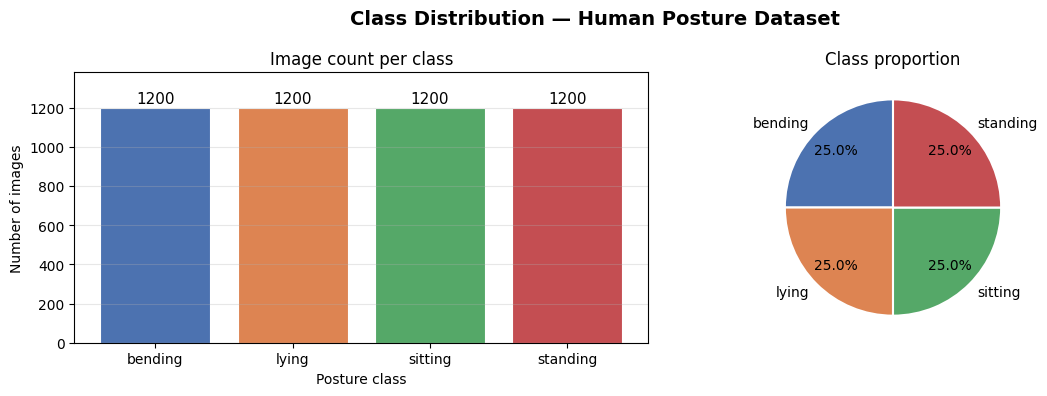


2.3  Sample images per class
   Figure saved → /kaggle/working/outputs/figures/fig2_sample_images.png


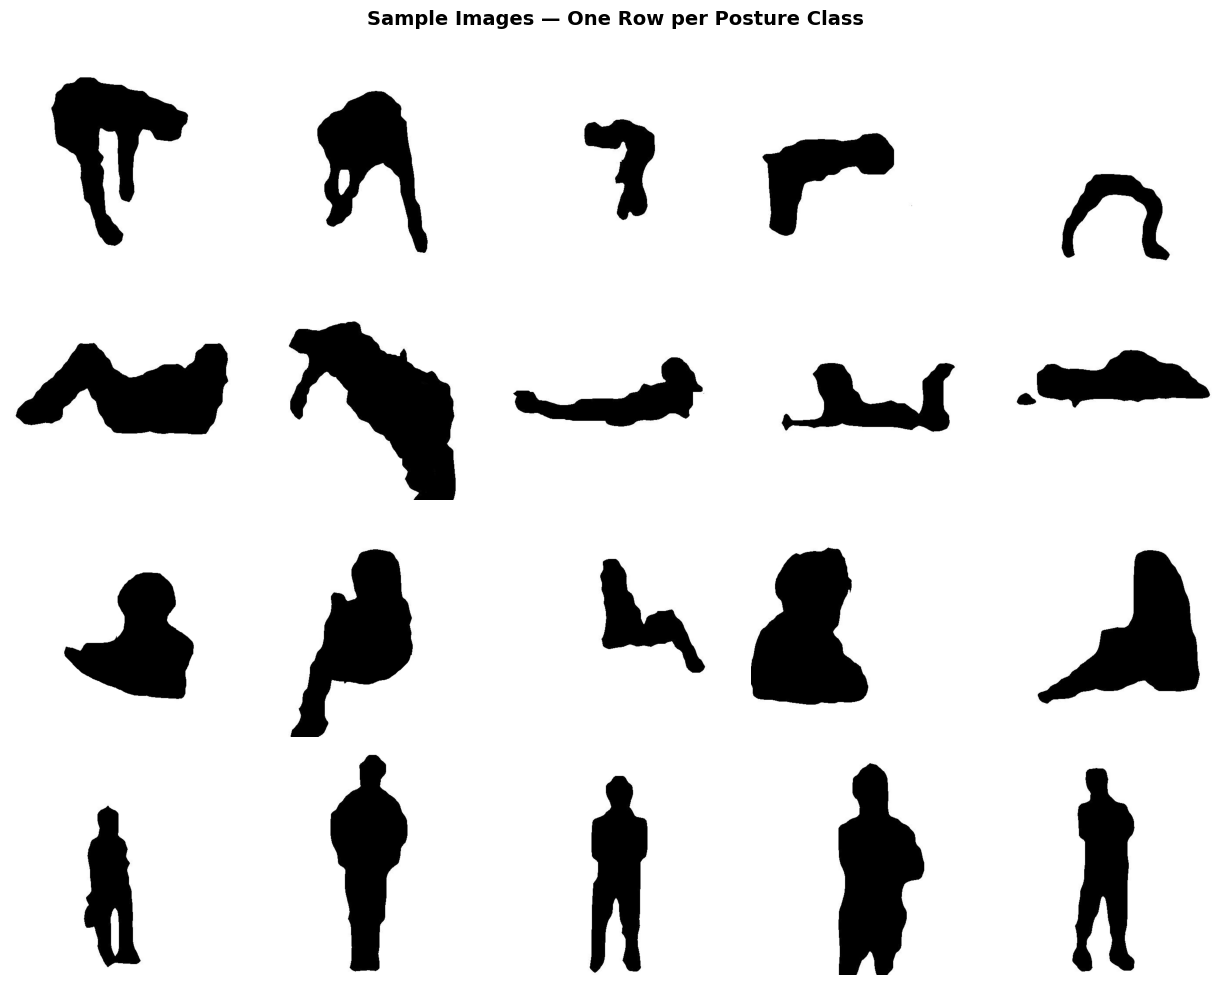


2.4  Image dimension analysis (sample of 200 images)
  Height  — min: 512  max: 512  mean: 512
  Width   — min: 512   max: 512   mean: 512
  Channels — unique values: {3}

  ➜ All images will be resized to 128×128 during preprocessing.

2.5  Pixel intensity distribution (sample of 100 images)
   Figure saved → /kaggle/working/outputs/figures/fig3_pixel_distribution.png


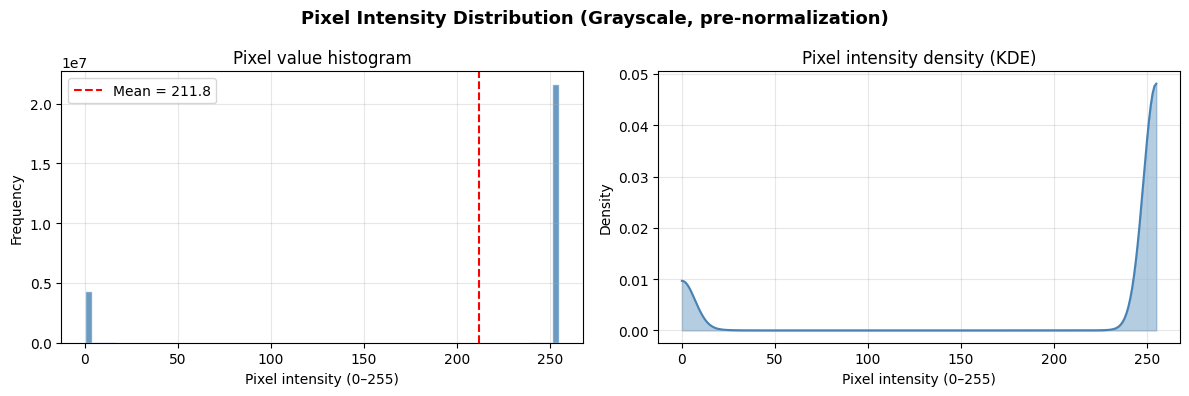


2.6  Dataset summary
   Class  Count Percentage  Train (~70%)  Val (~15%)  Test (~15%)
 bending   1200      25.0%           840         180          180
   lying   1200      25.0%           840         180          180
 sitting   1200      25.0%           840         180          180
standing   1200      25.0%           840         180          180

  Total images : 4800
  Input shape  : 128 × 128 × 3 (after resize)
  Num classes  : 4
  Class balance: ✅ Balanced

✅ Section 2 complete — EDA done.


In [3]:
# 2.1  SCAN DATASET STRUCTURE
print("=" * 55)
print("2.1  Scanning dataset folder structure")
print("=" * 55)
 
# Collect all image paths and their labels
image_paths  = []
image_labels = []
 
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}
 
for class_name in CLASS_NAMES:
    class_folder = DATASET_PATH / class_name
    if not class_folder.exists():
        print(f"  ⚠️  Folder not found: {class_folder}")
        continue
    files = [
        f for f in class_folder.iterdir()
        if f.suffix.lower() in VALID_EXTENSIONS
    ]
    image_paths.extend(files)
    image_labels.extend([class_name] * len(files))
    print(f"  {class_name:<12} → {len(files):>5} images  |  {class_folder}")
 
print(f"\n  Total images found: {len(image_paths)}")
 
# Build a summary DataFrame
df = pd.DataFrame({
    'filepath': image_paths,
    'label':    image_labels
})
 
# 2.2  CLASS DISTRIBUTION
print("\n" + "=" * 55)
print("2.2  Class distribution")
print("=" * 55)
 
class_counts = df['label'].value_counts().reindex(CLASS_NAMES)
print(class_counts.to_string())
 
total = class_counts.sum()
print(f"\n  Class balance check:")
for cls, cnt in class_counts.items():
    pct = cnt / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {cls:<12}  {cnt:>5}  ({pct:.1f}%)  {bar}")
 
# --- Figure 1: Class distribution bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution — Human Posture Dataset', fontsize=14, fontweight='bold')
 
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
 
# Bar chart
axes[0].bar(CLASS_NAMES, class_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Image count per class')
axes[0].set_ylabel('Number of images')
axes[0].set_xlabel('Posture class')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontsize=11)
axes[0].set_ylim(0, max(class_counts.values) * 1.15)
axes[0].grid(axis='y', alpha=0.3)
 
# Pie chart
axes[1].pie(
    class_counts.values,
    labels=CLASS_NAMES,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
axes[1].set_title('Class proportion')
 
plt.tight_layout()
save_figure(fig, 'fig1_class_distribution.png')
plt.show()
 
# 2.3  SAMPLE IMAGES PER CLASS
print("\n" + "=" * 55)
print("2.3  Sample images per class")
print("=" * 55)
 
N_SAMPLES = 5   # show 5 samples per class
 
fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES, figsize=(N_SAMPLES * 2.5, NUM_CLASSES * 2.5))
fig.suptitle('Sample Images — One Row per Posture Class', fontsize=14, fontweight='bold')
 
for row_idx, class_name in enumerate(CLASS_NAMES):
    class_df  = df[df['label'] == class_name]
    samples   = class_df.sample(min(N_SAMPLES, len(class_df)), random_state=SEED)
 
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['filepath']).convert('RGB')
        ax  = axes[row_idx][col_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(class_name, fontsize=12, fontweight='bold', rotation=90, labelpad=10)
 
plt.tight_layout()
save_figure(fig, 'fig2_sample_images.png')
plt.show()
 
# 2.4  IMAGE DIMENSION ANALYSIS
print("\n" + "=" * 55)
print("2.4  Image dimension analysis (sample of 200 images)")
print("=" * 55)
 
sample_df = df.sample(min(200, len(df)), random_state=SEED)
widths, heights, channels = [], [], []
 
for _, row in sample_df.iterrows():
    img = np.array(Image.open(row['filepath']))
    heights.append(img.shape[0])
    widths.append(img.shape[1])
    channels.append(img.shape[2] if img.ndim == 3 else 1)
 
print(f"  Height  — min: {min(heights)}  max: {max(heights)}  mean: {np.mean(heights):.0f}")
print(f"  Width   — min: {min(widths)}   max: {max(widths)}   mean: {np.mean(widths):.0f}")
print(f"  Channels — unique values: {set(channels)}")
print(f"\n  ➜ All images will be resized to {IMG_HEIGHT}×{IMG_WIDTH} during preprocessing.")
 
# 2.5  PIXEL INTENSITY DISTRIBUTION
print("\n" + "=" * 55)
print("2.5  Pixel intensity distribution (sample of 100 images)")
print("=" * 55)
 
pixel_sample = df.sample(min(100, len(df)), random_state=SEED)
all_pixels = []
 
for _, row in pixel_sample.iterrows():
    img = np.array(Image.open(row['filepath']).convert('L'))  # grayscale
    all_pixels.append(img.flatten())
 
all_pixels = np.concatenate(all_pixels)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Pixel Intensity Distribution (Grayscale, pre-normalization)', fontsize=13, fontweight='bold')
 
# Histogram
axes[0].hist(all_pixels, bins=64, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Pixel value histogram')
axes[0].set_xlabel('Pixel intensity (0–255)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(all_pixels.mean(), color='red', linestyle='--', label=f'Mean = {all_pixels.mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)
 
# KDE
from scipy.stats import gaussian_kde
kde_x = np.linspace(0, 255, 256)
kde   = gaussian_kde(all_pixels[::50])   # subsample for speed
axes[1].fill_between(kde_x, kde(kde_x), alpha=0.4, color='steelblue')
axes[1].plot(kde_x, kde(kde_x), color='steelblue')
axes[1].set_title('Pixel intensity density (KDE)')
axes[1].set_xlabel('Pixel intensity (0–255)')
axes[1].set_ylabel('Density')
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
save_figure(fig, 'fig3_pixel_distribution.png')
plt.show()
 
# 2.6  DATASET SUMMARY TABLE
print("\n" + "=" * 55)
print("2.6  Dataset summary")
print("=" * 55)
 
summary = pd.DataFrame({
    'Class':        CLASS_NAMES,
    'Count':        [class_counts[c] for c in CLASS_NAMES],
    'Percentage':   [f"{class_counts[c]/total*100:.1f}%" for c in CLASS_NAMES],
    'Train (~70%)': [int(class_counts[c] * 0.70) for c in CLASS_NAMES],
    'Val (~15%)':   [int(class_counts[c] * 0.15) for c in CLASS_NAMES],
    'Test (~15%)':  [int(class_counts[c] * 0.15) for c in CLASS_NAMES],
})
 
print(summary.to_string(index=False))
print(f"\n  Total images : {total}")
print(f"  Input shape  : {IMG_HEIGHT} × {IMG_WIDTH} × {IMG_CHANNELS} (after resize)")
print(f"  Num classes  : {NUM_CLASSES}")
print(f"  Class balance: {'✅ Balanced' if class_counts.std() < 50 else '⚠️  Imbalanced — consider class weights'}")
 
print("\n✅ Section 2 complete — EDA done.")
 

3.1  Train / Validation / Test Split
  Training   :  3360 images
  Validation :   720 images
  Test       :   720 images
  Total      :  4800 images

  Train class balance:
    bending        840
    lying          840
    sitting        840
    standing       840

  Validation class balance:
    bending        180
    lying          180
    sitting        180
    standing       180

  Test class balance:
    bending        180
    lying          180
    sitting        180
    standing       180

3.2  Label encoding
  Mapping: {'bending': 0, 'lying': 1, 'sitting': 2, 'standing': 3}

3.3  Building tf.data pipelines


I0000 00:00:1780968643.686768      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780968643.692837      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  train_ds : 3360 images → 105 batches of 32
  val_ds   : 720 images   → 23 batches of 32
  test_ds  : 720 images  → 23 batches of 32

  Batch shape — images: (32, 128, 128, 3), labels: (32,)
  Pixel range — min: 0.000, max: 1.000

3.4  Visualising original vs augmented images


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0045704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0062879].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0062671].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0054257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0009818].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.008642].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.002951].
Clipping input data to the valid ran

   Figure saved → /kaggle/working/outputs/figures/fig4_augmentation_examples.png


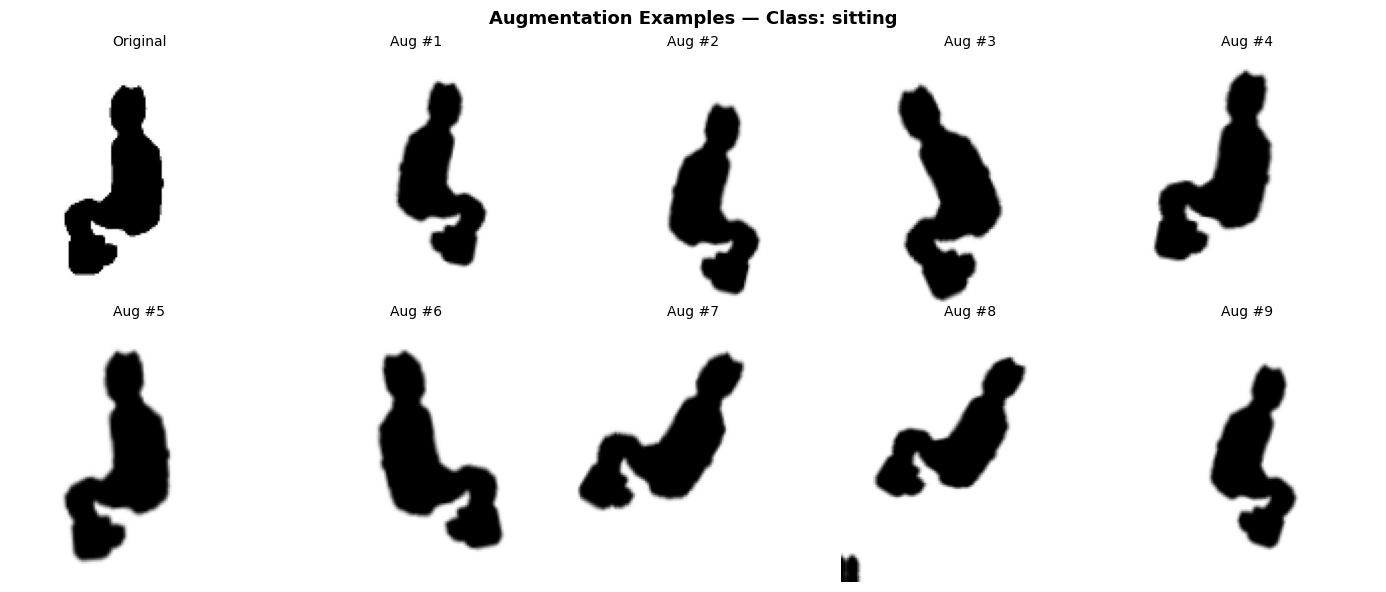


3.5  Augmentation strategy summary
  Augmentation                   Rationale
  ----------------------------------------------------------------------
  Random horizontal flip         Mirrors posture — valid for symmetrical poses
  Random rotation (±18°)         Simulates camera tilt or subject orientation
  Random zoom (±10%)             Simulates distance variation from camera
  Random translation (±5%)       Simulates subject not centred in frame
  Random contrast (±10%)         Simulates silhouette edge sharpness variation

✅ Section 3 complete — data pipeline.


In [4]:
from sklearn.model_selection import train_test_split
 
# 3.1  TRAIN / VALIDATION / TEST SPLIT
print("=" * 55)
print("3.1  Train / Validation / Test Split")
print("=" * 55)
 
# Convert paths to strings for sklearn compatibility
all_paths  = [str(p) for p in df['filepath'].tolist()]
all_labels = df['label'].tolist()
 
# Step 1: Split off test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_paths, all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,      # preserve class proportions in every split
    random_state=SEED
)
 
# Step 2: Split remaining into train (70%) and val (15%)
# val_ratio relative to trainval portion = 0.15 / (1 - 0.15) ≈ 0.1765
val_ratio_adjusted = VAL_RATIO / (1 - TEST_RATIO)
 
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_ratio_adjusted,
    stratify=y_trainval,
    random_state=SEED
)
 
print(f"  Training   : {len(X_train):>5} images")
print(f"  Validation : {len(X_val):>5} images")
print(f"  Test       : {len(X_test):>5} images")
print(f"  Total      : {len(X_train)+len(X_val)+len(X_test):>5} images")
 
# Verify class balance in each split
def split_balance(labels, split_name):
    from collections import Counter
    counts = Counter(labels)
    print(f"\n  {split_name} class balance:")
    for cls in CLASS_NAMES:
        print(f"    {cls:<12} {counts[cls]:>5}")
 
split_balance(y_train, "Train")
split_balance(y_val,   "Validation")
split_balance(y_test,  "Test")
 
# 3.2  LABEL ENCODING
print("\n" + "=" * 55)
print("3.2  Label encoding")
print("=" * 55)
 
# Map class names → integer indices (alphabetical order)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}
 
print(f"  Mapping: {CLASS_TO_IDX}")
 
y_train_enc = [CLASS_TO_IDX[l] for l in y_train]
y_val_enc   = [CLASS_TO_IDX[l] for l in y_val]
y_test_enc  = [CLASS_TO_IDX[l] for l in y_test]
 
# 3.3  tf.data PIPELINE BUILDER
print("\n" + "=" * 55)
print("3.3  Building tf.data pipelines")
print("=" * 55)
 
# --- Image loading and preprocessing function ---
def load_and_preprocess(path, label):
    """
    Load an image from disk, resize to IMG_HEIGHT×IMG_WIDTH,
    convert to float32, and normalise pixels to [0, 1].
    """
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=IMG_CHANNELS, expand_animations=False)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0   # normalise to [0, 1]
    image.set_shape([IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])
    return image, label
 
# --- Augmentation function (training only) ---
def augment(image, label):
    """
    Domain-appropriate augmentation for posture silhouettes.
    We avoid colour jitter (silhouettes are grayscale-like)
    and focus on geometric transforms that simulate real-world variation.
    """
    # Random horizontal flip (mirror posture — valid for most poses)
    image = tf.image.random_flip_left_right(image)
 
    # Random brightness (lighting variation)
    image = tf.image.random_brightness(image, max_delta=0.15)
 
    # Random contrast (silhouette edge sharpness variation)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
 
    # Random rotation ±15° via TensorFlow
    angle = tf.random.uniform([], -0.26, 0.26)  # radians (≈ ±15°)
    image = tf.keras.preprocessing.image.apply_affine_transform(
        image.numpy(), theta=angle * (180 / 3.14159), fill_mode='nearest'
    ) if False else image  # placeholder — use tf.raw_ops below for graph mode
 
    # Clip values back to [0, 1] after augmentation
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

 
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),          # ±10% of 2π ≈ ±18°
    layers.RandomZoom(0.1),              # ±10% zoom
    layers.RandomTranslation(0.05, 0.05),# ±5% shift height & width
    layers.RandomContrast(0.1),
], name="data_augmentation")
 
# --- Dataset factory ---
AUTOTUNE = tf.data.AUTOTUNE
 
def make_dataset(paths, labels, training=False):
    """
    Build a tf.data.Dataset from file paths and integer labels.
    - training=True  → apply augmentation + shuffle
    - training=False → no augmentation, no shuffle
    """
    path_ds  = tf.data.Dataset.from_tensor_slices(paths)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    ds = tf.data.Dataset.zip((path_ds, label_ds))
 
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
 
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(
            # clip_by_value ensures RandomContrast cannot push pixels outside [0, 1]
            lambda img, lbl: (
                tf.clip_by_value(
                    data_augmentation(img, training=True),
                    0.0,
                    1.0
                ),
                lbl
            ),
            num_parallel_calls=AUTOTUNE
        )
 
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)   # pre-load next batch while GPU trains on current
    return ds
 
# Build all three datasets
train_ds = make_dataset(X_train, y_train_enc, training=True)
val_ds   = make_dataset(X_val,   y_val_enc,   training=False)
test_ds  = make_dataset(X_test,  y_test_enc,  training=False)
 
print(f"  train_ds : {len(X_train)} images → {len(train_ds)} batches of {BATCH_SIZE}")
print(f"  val_ds   : {len(X_val)} images   → {len(val_ds)} batches of {BATCH_SIZE}")
print(f"  test_ds  : {len(X_test)} images  → {len(test_ds)} batches of {BATCH_SIZE}")
 
# Quick shape check
for images, labels in train_ds.take(1):
    print(f"\n  Batch shape — images: {images.shape}, labels: {labels.shape}")
    print(f"  Pixel range — min: {images.numpy().min():.3f}, max: {images.numpy().max():.3f}")
 
# 3.4  VISUALISE AUGMENTED SAMPLES
print("\n" + "=" * 55)
print("3.4  Visualising original vs augmented images")
print("=" * 55)
 
# Load a single image and show 8 augmented versions
sample_path  = X_train[0]
sample_label = y_train[0]
 
raw   = tf.io.read_file(sample_path)
orig  = tf.image.decode_image(raw, channels=IMG_CHANNELS, expand_animations=False)
orig  = tf.image.resize(orig, [IMG_HEIGHT, IMG_WIDTH])
orig  = tf.cast(orig, tf.float32) / 255.0
 
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(
    f'Augmentation Examples — Class: {sample_label}',
    fontsize=13, fontweight='bold'
)
 
# Original
axes[0][0].imshow(orig.numpy())
axes[0][0].set_title('Original', fontsize=10)
axes[0][0].axis('off')
 
# 9 augmented versions
aug_count = 0
for row in range(2):
    start_col = 1 if row == 0 else 0
    for col in range(start_col, 5):
        if aug_count >= 9:
            break
        aug_img = data_augmentation(orig, training=True)
        axes[row][col].imshow(aug_img.numpy())
        axes[row][col].set_title(f'Aug #{aug_count+1}', fontsize=10)
        axes[row][col].axis('off')
        aug_count += 1
 
plt.tight_layout()
save_figure(fig, 'fig4_augmentation_examples.png')
plt.show()
 
# 3.5  AUGMENTATION STRATEGY SUMMARY
print("\n" + "=" * 55)
print("3.5  Augmentation strategy summary")
print("=" * 55)
 
aug_summary = {
    'Random horizontal flip':   'Mirrors posture — valid for symmetrical poses',
    'Random rotation (±18°)':   'Simulates camera tilt or subject orientation',
    'Random zoom (±10%)':       'Simulates distance variation from camera',
    'Random translation (±5%)': 'Simulates subject not centred in frame',
    'Random contrast (±10%)':   'Simulates silhouette edge sharpness variation',
}
 
print(f"  {'Augmentation':<30} {'Rationale'}")
print("  " + "-" * 70)
for k, v in aug_summary.items():
    print(f"  {k:<30} {v}")
 
print("\n✅ Section 3 complete — data pipeline.")

4.1  Custom CNN Architecture


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1_1 (Activation)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1_2 (Activation)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2_1 (Activation)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2_2 (Activation)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3_1 (Activation)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3_2 (Activation)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4_1 (BatchNormalization)      │ (None, 16, 16, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act4_1 (Activation)             │ (None, 16, 16, 256)    │             

 Total params: 1,243,940 (4.75 MB)

 Trainable params: 1,241,508 (4.74 MB)

...


  Total parameters     : 1,243,940
  Trainable parameters : 1,241,508

4.2  Compiling the model
  Optimizer  : Adam (lr=0.001)
  Loss       : sparse_categorical_crossentropy
  Metrics    : accuracy

4.3  Setting up training callbacks
  ✅ EarlyStopping     — patience=8, monitors val_loss
  ✅ ModelCheckpoint   — saves best model to disk
  ✅ ReduceLROnPlateau — halves LR after 4 stagnant epochs

4.4  Training the Custom CNN
  Max epochs : 50
  Batch size : 32
  Train size : 3360 images
  Val size   : 720 images
  Starting training...

Epoch 1/50


I0000 00:00:1780968909.600472     205 service.cc:152] XLA service 0x259f6bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780968909.600528     205 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780968909.600535     205 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780968910.746266     205 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-09 01:35:14.580586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 01:35:14.734930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 01:35:16.216298: E external/local_xla/xl

  2/105 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.2734 - loss: 1.9523  

I0000 00:00:1780968922.370571     205 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5366 - loss: 1.2164
Epoch 1: val_loss improved from None to 1.92039, saving model to /kaggle/working/outputs/models/best_custom_cnn.keras

Epoch 1: finished saving model to /kaggle/working/outputs/models/best_custom_cnn.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.6065 - loss: 1.0303 - val_accuracy: 0.2500 - val_loss: 1.9204 - learning_rate: 0.0010
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6794 - loss: 0.8702
Epoch 2: val_loss did not improve from 1.92039
105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.6833 - loss: 0.8500 - val_accuracy: 0.3278 - val_loss: 2.0394 - learning_rate: 0.0010
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7283 - loss: 0.7822
Epoch 3: val_loss improved from 1.92039 to 1.24451, saving model to /kaggle/working/outputs/models/best_custom_cnn.keras

Epoch 3: finished saving model to /kaggle/working/outputs/models/best_custom_cnn.ker

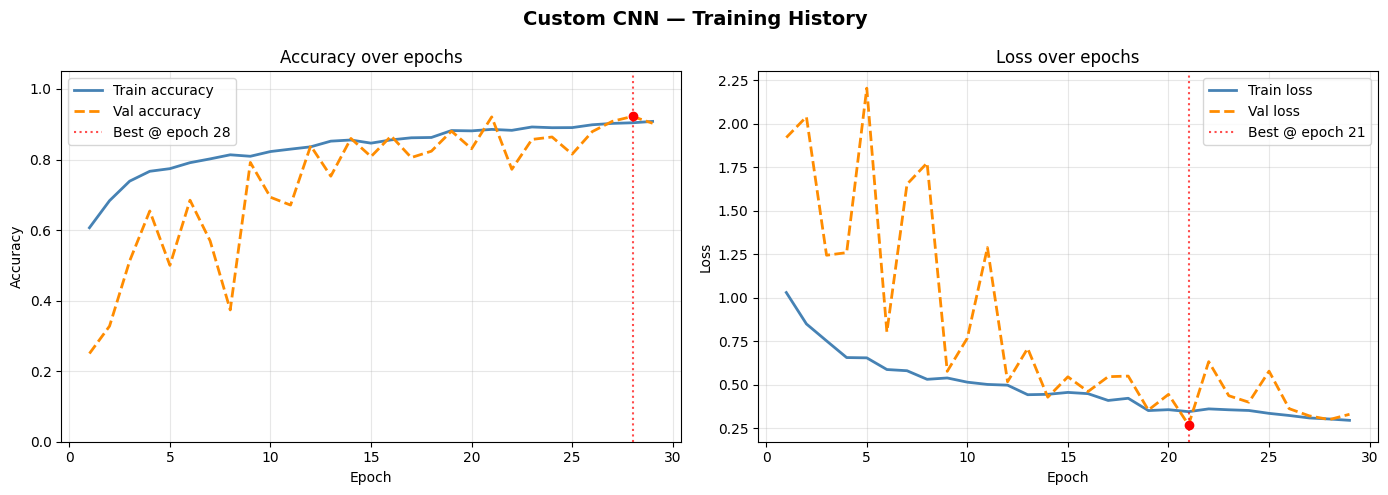


4.6  CNN Architecture Summary
  Layer            Output Shape     Details
  ----------------------------------------------------------------------
  Input            128×128×3        —
  Conv Block 1     64×64×32         2×Conv2D(32) + BN + ReLU + MaxPool
  Conv Block 2     32×32×64         2×Conv2D(64) + BN + ReLU + MaxPool
  Conv Block 3     16×16×128        2×Conv2D(128) + BN + ReLU + MaxPool
  Conv Block 4     8×8×256          2×Conv2D(256) + BN + ReLU + MaxPool
  GAP              256              GlobalAveragePooling2D
  Dense            256              Dense + BN + ReLU + Dropout(0.5)
  Output           4                Dense + Softmax

  Total trainable parameters: 1,241,508

4.7  Saving model
  Best model  → /kaggle/working/outputs/models/best_custom_cnn.keras
  Final model → /kaggle/working/outputs/models/custom_cnn_final.keras

✅ Section 4 complete — Custom CNN trained.
   Best val accuracy : 92.22%


In [5]:
# 4.1  MODEL ARCHITECTURE
print("=" * 55)
print("4.1  Custom CNN Architecture")
print("=" * 55)
 
def build_custom_cnn(input_shape, num_classes):
    """
    Custom CNN for human posture classification.
 
    Architecture overview:
      Block 1: 32 filters  — learn low-level edges / silhouette contours
      Block 2: 64 filters  — learn mid-level shape patterns
      Block 3: 128 filters — learn high-level posture features
      Block 4: 256 filters — learn class-discriminative representations
      Head   : GlobalAveragePooling → Dense → Dropout → Softmax
 
    Design choices:
      - BatchNormalization after every Conv layer: stabilises training,
        allows higher learning rates, reduces sensitivity to initialisation.
      - MaxPooling2D: progressively reduces spatial size, adds translation
        invariance.
      - GlobalAveragePooling2D instead of Flatten: fewer parameters,
        built-in spatial averaging, less prone to overfitting.
      - L2 regularisation on Dense layer: penalises large weights.
      - Dropout(0.5): the strongest regulariser before the output layer.
    """
    inputs = keras.Input(shape=input_shape, name="input_image")
 
    # ----- Block 1: 32 filters -----
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu', name='act1_1')(x)
 
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='act1_2')(x)
 
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)   # 128→64
 
    # ----- Block 2: 64 filters -----
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='act2_1')(x)
 
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='act2_2')(x)
 
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)   # 64→32
 
    # ----- Block 3: 128 filters -----
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu', name='act3_1')(x)
 
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu', name='act3_2')(x)
 
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)   # 32→16
 
    # ----- Block 4: 256 filters -----
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv4_1')(x)
    x = layers.BatchNormalization(name='bn4_1')(x)
    x = layers.Activation('relu', name='act4_1')(x)
 
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv4_2')(x)
    x = layers.BatchNormalization(name='bn4_2')(x)
    x = layers.Activation('relu', name='act4_2')(x)
 
    x = layers.MaxPooling2D((2, 2), name='pool4')(x)   # 16→8
 
    # ----- Classification Head -----
    x = layers.GlobalAveragePooling2D(name='gap')(x)
 
    x = layers.Dense(
        256,
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense1'
    )(x)
    x = layers.BatchNormalization(name='bn_dense')(x)
    x = layers.Activation('relu', name='act_dense')(x)
    x = layers.Dropout(0.5, name='dropout')(x)
 
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
 
    model = keras.Model(inputs=inputs, outputs=outputs, name="CustomCNN")
    return model
 
 
custom_cnn = build_custom_cnn(INPUT_SHAPE, NUM_CLASSES)
custom_cnn.summary()
 
# Count parameters
total_params     = custom_cnn.count_params()
trainable_params = sum([tf.size(w).numpy() for w in custom_cnn.trainable_weights])
print(f"\n  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
 
# 4.2  COMPILE
print("\n" + "=" * 55)
print("4.2  Compiling the model")
print("=" * 55)
 
custom_cnn.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',  # labels are integers, not one-hot
    metrics=['accuracy']
)
 
print(f"  Optimizer  : Adam (lr={LEARNING_RATE})")
print(f"  Loss       : sparse_categorical_crossentropy")
print(f"  Metrics    : accuracy")
 
# 4.3  CALLBACKS
print("\n" + "=" * 55)
print("4.3  Setting up training callbacks")
print("=" * 55)
 
cnn_model_path = str(MODELS_DIR / 'best_custom_cnn.keras')
 
callbacks_cnn = [
    # Stop training when val_loss stops improving for 8 consecutive epochs
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,   # revert to best epoch automatically
        verbose=1
    ),
    # Save only the best model (lowest val_loss) to disk
    ModelCheckpoint(
        filepath=cnn_model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Halve the learning rate if val_loss plateaus for 4 epochs
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
]
 
print("  ✅ EarlyStopping     — patience=8, monitors val_loss")
print("  ✅ ModelCheckpoint   — saves best model to disk")
print("  ✅ ReduceLROnPlateau — halves LR after 4 stagnant epochs")
 
# 4.4  TRAINING
print("\n" + "=" * 55)
print("4.4  Training the Custom CNN")
print("=" * 55)
print(f"  Max epochs : {EPOCHS}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Train size : {len(X_train)} images")
print(f"  Val size   : {len(X_val)} images")
print("  Starting training...\n")
 
history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_cnn,
    verbose=1
)
 
actual_epochs = len(history_cnn.history['loss'])
best_val_acc  = max(history_cnn.history['val_accuracy'])
best_val_loss = min(history_cnn.history['val_loss'])
 
print(f"\n  Training stopped at epoch : {actual_epochs}")
print(f"  Best val accuracy          : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"  Best val loss              : {best_val_loss:.4f}")

# 4.5  TRAINING CURVES
print("\n" + "=" * 55)
print("4.5  Plotting training curves")
print("=" * 55)
 
epochs_range = range(1, actual_epochs + 1)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training History', fontsize=14, fontweight='bold')
 
# --- Accuracy ---
axes[0].plot(epochs_range, history_cnn.history['accuracy'],
             label='Train accuracy', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, history_cnn.history['val_accuracy'],
             label='Val accuracy', color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.05)
 
# Mark best val accuracy
best_acc_epoch = history_cnn.history['val_accuracy'].index(best_val_acc) + 1
axes[0].axvline(best_acc_epoch, color='red', linestyle=':', alpha=0.7,
                label=f'Best @ epoch {best_acc_epoch}')
axes[0].scatter(best_acc_epoch, best_val_acc, color='red', zorder=5)
axes[0].legend()
 
# --- Loss ---
axes[1].plot(epochs_range, history_cnn.history['loss'],
             label='Train loss', color='steelblue', linewidth=2)
axes[1].plot(epochs_range, history_cnn.history['val_loss'],
             label='Val loss', color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
# Mark best val loss epoch
best_loss_epoch = history_cnn.history['val_loss'].index(best_val_loss) + 1
axes[1].axvline(best_loss_epoch, color='red', linestyle=':', alpha=0.7,
                label=f'Best @ epoch {best_loss_epoch}')
axes[1].scatter(best_loss_epoch, best_val_loss, color='red', zorder=5)
axes[1].legend()
 
plt.tight_layout()
save_figure(fig, 'fig5_cnn_training_curves.png')
plt.show()
 
# 4.6  ARCHITECTURE DIAGRAM (text-based)
print("\n" + "=" * 55)
print("4.6  CNN Architecture Summary")
print("=" * 55)
 
arch_rows = [
    ("Input",          f"{IMG_HEIGHT}×{IMG_WIDTH}×{IMG_CHANNELS}",  "—"),
    ("Conv Block 1",   "64×64×32",   "2×Conv2D(32) + BN + ReLU + MaxPool"),
    ("Conv Block 2",   "32×32×64",   "2×Conv2D(64) + BN + ReLU + MaxPool"),
    ("Conv Block 3",   "16×16×128",  "2×Conv2D(128) + BN + ReLU + MaxPool"),
    ("Conv Block 4",   "8×8×256",    "2×Conv2D(256) + BN + ReLU + MaxPool"),
    ("GAP",            "256",        "GlobalAveragePooling2D"),
    ("Dense",          "256",        "Dense + BN + ReLU + Dropout(0.5)"),
    ("Output",         f"{NUM_CLASSES}",    "Dense + Softmax"),
]
 
print(f"  {'Layer':<16} {'Output Shape':<16} {'Details'}")
print("  " + "-" * 70)
for layer, shape, detail in arch_rows:
    print(f"  {layer:<16} {shape:<16} {detail}")
 
print(f"\n  Total trainable parameters: {trainable_params:,}")
 
# 4.7  SAVE MODEL
print("\n" + "=" * 55)
print("4.7  Saving model")
print("=" * 55)
 
final_cnn_path = str(MODELS_DIR / 'custom_cnn_final.keras')
custom_cnn.save(final_cnn_path)
print(f"  Best model  → {cnn_model_path}")
print(f"  Final model → {final_cnn_path}")
 
print("\n✅ Section 4 complete — Custom CNN trained.")
print(f"   Best val accuracy : {best_val_acc*100:.2f}%")

 

5.1  MobileNetV2
  Strengths: Very lightweight (~3.4M params), fast inference.
  Ideal for: Mobile/edge deployment, quick prototyping.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_head (Activation)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,972 (9.87 MB)

 Trainable params: 329,476 (1.26 MB)

...


  Phase 1: Feature extraction (base frozen)
Epoch 1/10


2026-06-09 01:46:48.596588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 01:46:48.734206: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7183 - loss: 0.8162

2026-06-09 01:47:11.492824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 01:47:11.629752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.40096, saving model to /kaggle/working/outputs/models/best_mobilenetv2.keras

Epoch 1: finished saving model to /kaggle/working/outputs/models/best_mobilenetv2.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 42s 219ms/step - accuracy: 0.7905 - loss: 0.6309 - val_accuracy: 0.8722 - val_loss: 0.4010 - learning_rate: 0.0010
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8228 - loss: 0.5213
Epoch 2: val_loss improved from 0.40096 to 0.36890, saving model to /kaggle/working/outputs/models/best_mobilenetv2.keras

Epoch 2: finished saving model to /kaggle/working/outputs/models/best_mobilenetv2.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.8330 - loss: 0.4891 - val_accuracy: 0.8875 - val_loss: 0.3689 - learning_rate: 0.0010
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8498 - loss: 0.4567
Epoch 3: val_loss improved from 0.36890 to 0.35927, saving model to /kaggle/working/outputs/models/best_mobilenetv2.ker

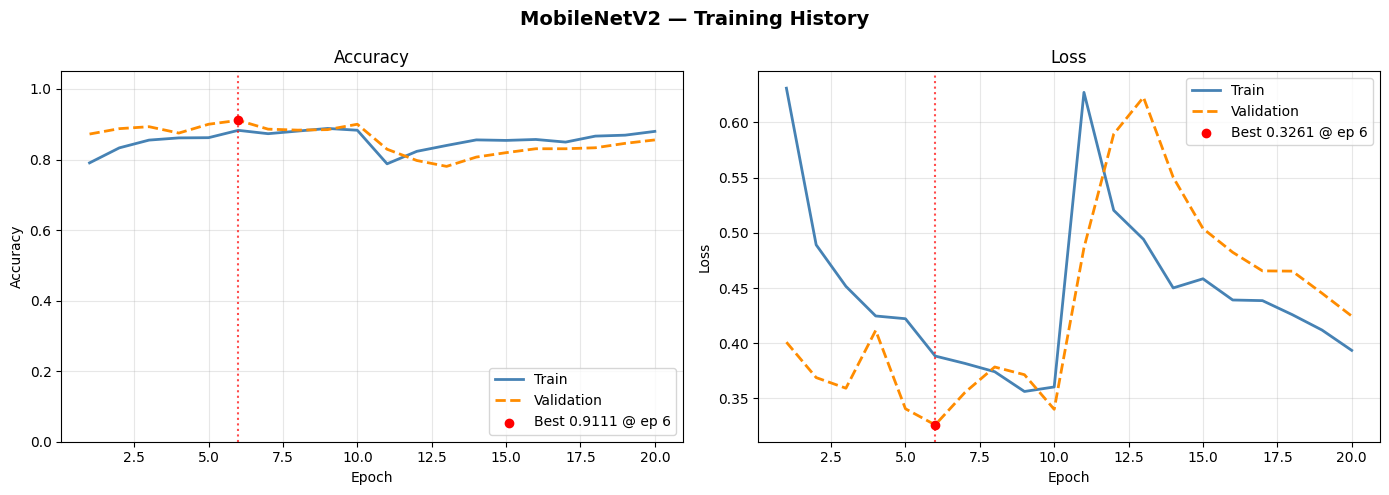


  ✅ MobileNetV2 done — Best val acc: 91.11%

5.2  Quick validation accuracy comparison

  Model                Val Accuracy
  ----------------------------------
  Custom CNN              92.22%  ███████████████████████████
  MobileNetV2             91.11%  ███████████████████████████

  🏆 Best model so far (val accuracy): Custom CNN

✅ Section 5 complete — MobileNetV2 transfer learning model trained.
   Model saved to: /kaggle/working/outputs/models


In [6]:
# 5.0  SHARED UTILITIES
 
def plot_training_curves(history, model_name, fig_filename):
    """Plot and save accuracy + loss curves for any model."""
    actual_epochs = len(history.history['loss'])
    epochs_range  = range(1, actual_epochs + 1)
 
    best_val_acc  = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    best_acc_ep   = history.history['val_accuracy'].index(best_val_acc) + 1
    best_loss_ep  = history.history['val_loss'].index(best_val_loss) + 1
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')
 
    # Accuracy
    axes[0].plot(epochs_range, history.history['accuracy'],
                 label='Train', color='steelblue', linewidth=2)
    axes[0].plot(epochs_range, history.history['val_accuracy'],
                 label='Validation', color='darkorange', linewidth=2, linestyle='--')
    axes[0].axvline(best_acc_ep, color='red', linestyle=':', alpha=0.7)
    axes[0].scatter(best_acc_ep, best_val_acc, color='red', zorder=5,
                    label=f'Best {best_val_acc:.4f} @ ep {best_acc_ep}')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
 
    # Loss
    axes[1].plot(epochs_range, history.history['loss'],
                 label='Train', color='steelblue', linewidth=2)
    axes[1].plot(epochs_range, history.history['val_loss'],
                 label='Validation', color='darkorange', linewidth=2, linestyle='--')
    axes[1].axvline(best_loss_ep, color='red', linestyle=':', alpha=0.7)
    axes[1].scatter(best_loss_ep, best_val_loss, color='red', zorder=5,
                    label=f'Best {best_val_loss:.4f} @ ep {best_loss_ep}')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    save_figure(fig, fig_filename)
    plt.show()
 
    return best_val_acc, best_val_loss, actual_epochs
 
 
def make_callbacks(model_name, models_dir):
    """Return a standard set of callbacks for any transfer learning model."""
    model_path = str(models_dir / f'best_{model_name}.keras')
    return [
        EarlyStopping(monitor='val_loss', patience=6,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=model_path, monitor='val_loss',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1),
    ], model_path
 
 
def build_transfer_model(base_model, num_classes, model_name):
    """
    Wrap a pretrained base with a custom classification head.
    Base is frozen initially for feature-extraction phase.
    """
    base_model.trainable = False   # freeze all base layers
 
    inputs = keras.Input(shape=INPUT_SHAPE, name="input_image")
 
    # Pretrained base 
    x = base_model(inputs, training=False)
 
    # Classification head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4),
                     name='dense1')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Activation('relu', name='act_head')(x)
    x = layers.Dropout(0.5, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           name='output')(x)
 
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model
 
 
# Storage for results across all transfer models
transfer_results = {}   # {model_name: {best_val_acc, best_val_loss, epochs}}
 
# 5.1  MobileNetV2
print("=" * 55)
print("5.1  MobileNetV2")
print("=" * 55)
print("  Strengths: Very lightweight (~3.4M params), fast inference.")
print("  Ideal for: Mobile/edge deployment, quick prototyping.\n")
 
# --- Build ---
base_mobilenet = MobileNetV2(
    input_shape=INPUT_SHAPE,
    include_top=False,          # remove ImageNet classifier head
    weights='imagenet'          # load pretrained ImageNet weights
)
model_mobilenet = build_transfer_model(base_mobilenet, NUM_CLASSES, 'MobileNetV2')
model_mobilenet.summary()
 
# --- Phase 1: Feature Extraction (base frozen) ---
print("\n  Phase 1: Feature extraction (base frozen)")
model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 
callbacks_mn, mn_path = make_callbacks('mobilenetv2', MODELS_DIR)
 
history_mn_phase1 = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,                  # head trains quickly; EarlyStopping handles early stop
    callbacks=callbacks_mn,
    verbose=1
)
 
print(f"\n  Phase 1 best val acc: {max(history_mn_phase1.history['val_accuracy']):.4f}")
 
# --- Phase 2: Fine-Tuning ---
print("\n  Phase 2: Fine-tuning (top 30 layers unfrozen)")
 
base_mobilenet.trainable = True
# Freeze all layers except the last 30
for layer in base_mobilenet.layers[:-30]:
    layer.trainable = False
 
# Recompile with a much lower LR to avoid destroying pretrained weights
model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
 
callbacks_mn_ft, _ = make_callbacks('mobilenetv2_finetuned', MODELS_DIR)
 
history_mn_phase2 = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,                  
    callbacks=callbacks_mn_ft,
    verbose=1
)
 
# Combine both phase histories for plotting
def combine_histories(h1, h2):
    """Concatenate two Keras History objects into one dict."""
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    class FakeHistory:
        def __init__(self, d): self.history = d
    return FakeHistory(combined)
 
history_mn = combine_histories(history_mn_phase1, history_mn_phase2)
 
best_acc_mn, best_loss_mn, epochs_mn = plot_training_curves(
    history_mn, 'MobileNetV2', 'fig6_mobilenetv2_curves.png'
)
 
# Save
model_mobilenet.save(str(MODELS_DIR / 'mobilenetv2_final.keras'))
transfer_results['MobileNetV2'] = {
    'best_val_acc':  best_acc_mn,
    'best_val_loss': best_loss_mn,
    'total_epochs':  epochs_mn,
    'model':         model_mobilenet,
    'history':       history_mn,
}
 
print(f"\n  ✅ MobileNetV2 done — Best val acc: {best_acc_mn*100:.2f}%")
 
 
# 5.2  VALIDATION ACCURACY COMPARISON (QUICK PREVIEW)
print("\n" + "=" * 55)
print("5.2  Quick validation accuracy comparison")
print("=" * 55)
 
all_results = {
    'Custom CNN':  best_val_acc,    
    'MobileNetV2': best_acc_mn,
}
 
print(f"\n  {'Model':<18} {'Val Accuracy':>14}")
print("  " + "-" * 34)
for name, acc in sorted(all_results.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 30)
    print(f"  {name:<18} {acc*100:>10.2f}%  {bar}")
 
best_model_name = max(all_results, key=all_results.get)
print(f"\n  🏆 Best model so far (val accuracy): {best_model_name}")
 
print("\n✅ Section 5 complete — MobileNetV2 transfer learning model trained.")
print("   Model saved to:", MODELS_DIR)
 

6.1  Models to evaluate on test set
  1. Custom CNN   (trained from scratch — Section 4)
  2. MobileNetV2  (transfer learning — Section 5)

6.2  Running test-set evaluation

  ── Custom CNN ──
   Figure saved → /kaggle/working/outputs/figures/fig9_cm_custom_cnn.png


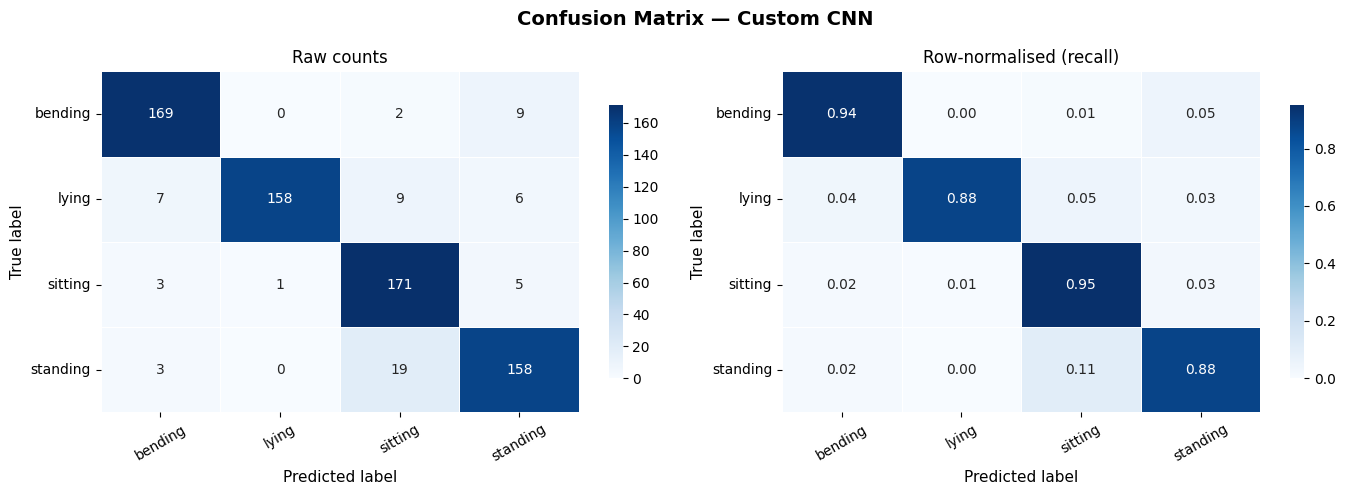


  Classification Report — Custom CNN
              precision    recall  f1-score   support

     bending     0.9286    0.9389    0.9337       180
       lying     0.9937    0.8778    0.9322       180
     sitting     0.8507    0.9500    0.8976       180
    standing     0.8876    0.8778    0.8827       180

    accuracy                         0.9111       720
   macro avg     0.9152    0.9111    0.9115       720
weighted avg     0.9152    0.9111    0.9115       720

   Figure saved → /kaggle/working/outputs/figures/fig10_roc_custom_cnn.png


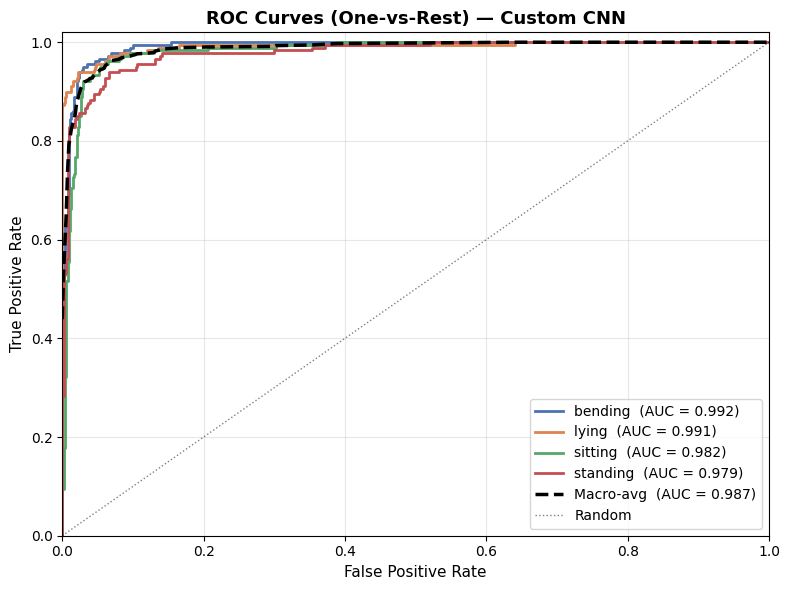

  Test accuracy  : 91.11%
  Macro AUC      : 0.9870
  Inference time : 3.17 ms/image

  ── MobileNetV2 ──
   Figure saved → /kaggle/working/outputs/figures/fig11_cm_mobilenetv2.png


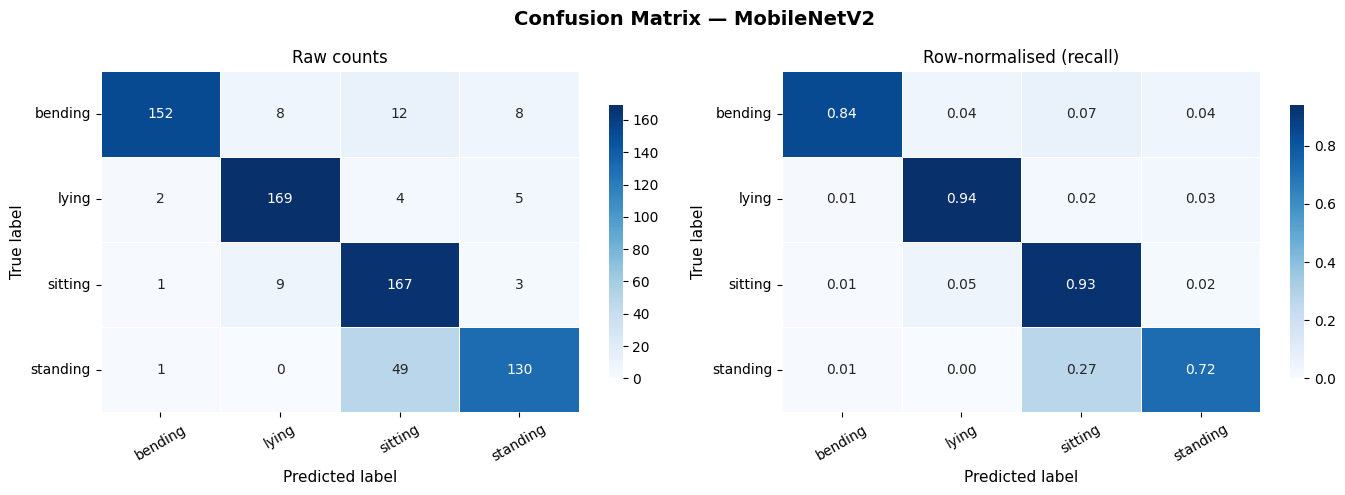


  Classification Report — MobileNetV2
              precision    recall  f1-score   support

     bending     0.9744    0.8444    0.9048       180
       lying     0.9086    0.9389    0.9235       180
     sitting     0.7198    0.9278    0.8107       180
    standing     0.8904    0.7222    0.7975       180

    accuracy                         0.8583       720
   macro avg     0.8733    0.8583    0.8591       720
weighted avg     0.8733    0.8583    0.8591       720

   Figure saved → /kaggle/working/outputs/figures/fig12_roc_mobilenetv2.png


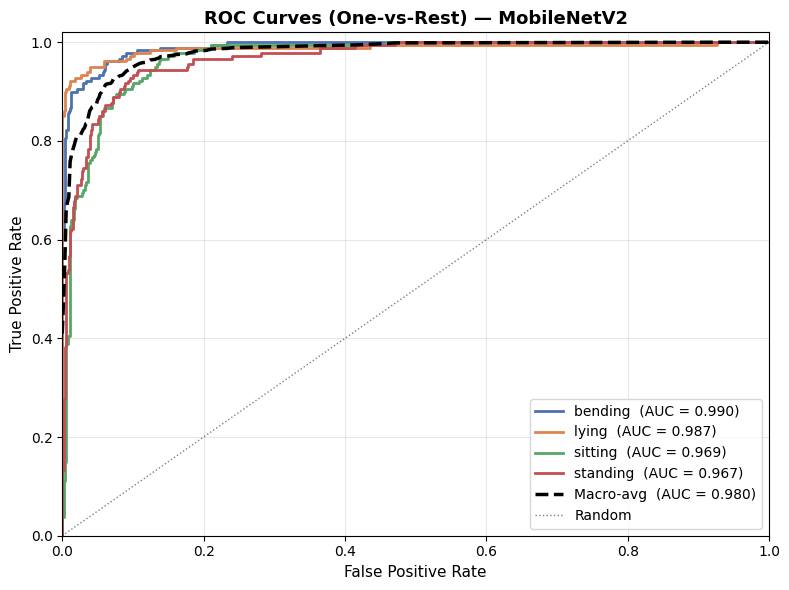

  Test accuracy  : 85.83%
  Macro AUC      : 0.9797
  Inference time : 2.95 ms/image

6.3  Model Comparison Table
         Model  Test Acc (%)  Macro F1  Macro Precision  Macro Recall  Macro AUC  Infer. (ms/img)
1   Custom CNN         91.11    0.9115           0.9152        0.9111     0.9870             3.17
2  MobileNetV2         85.83    0.8591           0.8733        0.8583     0.9797             2.95

  Table saved → /kaggle/working/outputs/model_comparison_table.csv

6.4  Comparison bar chart
   Figure saved → /kaggle/working/outputs/figures/fig17_model_comparison_bar.png


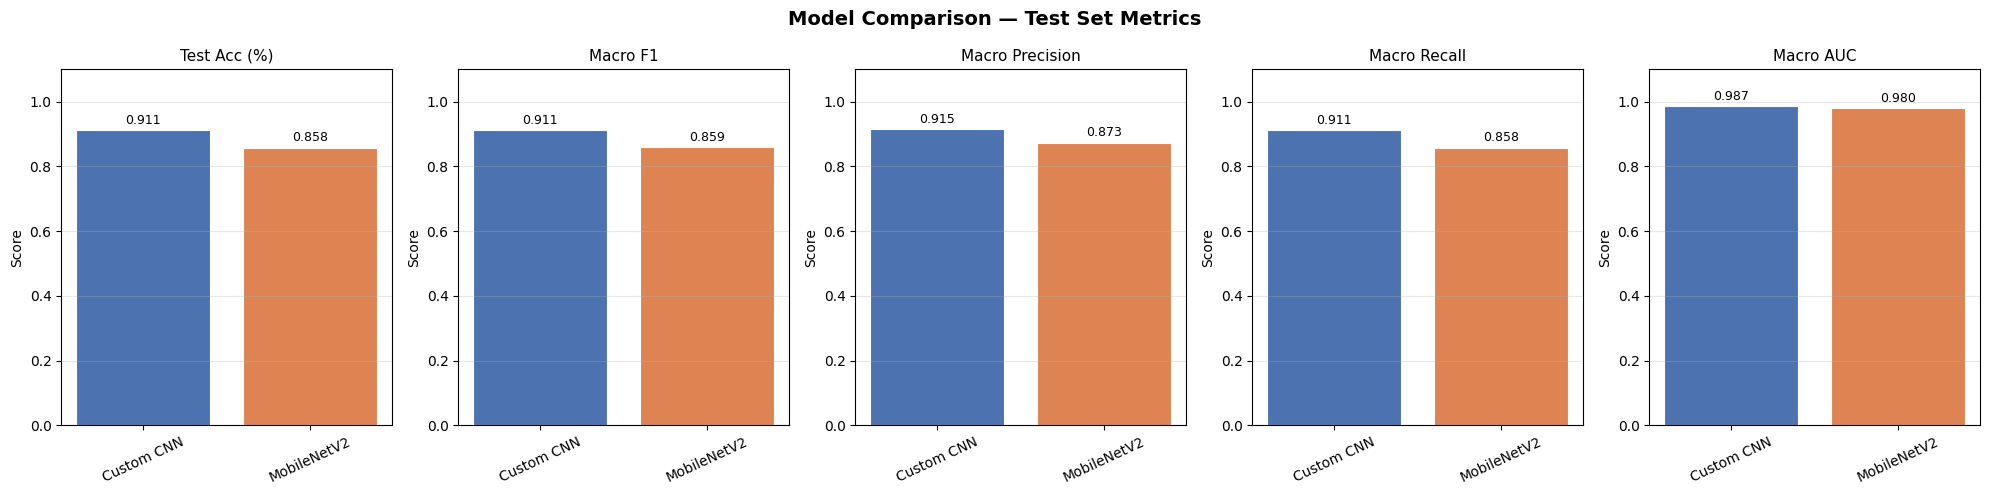


6.5  Per-class F1 heatmap
   Figure saved → /kaggle/working/outputs/figures/fig18_perclass_f1_heatmap.png


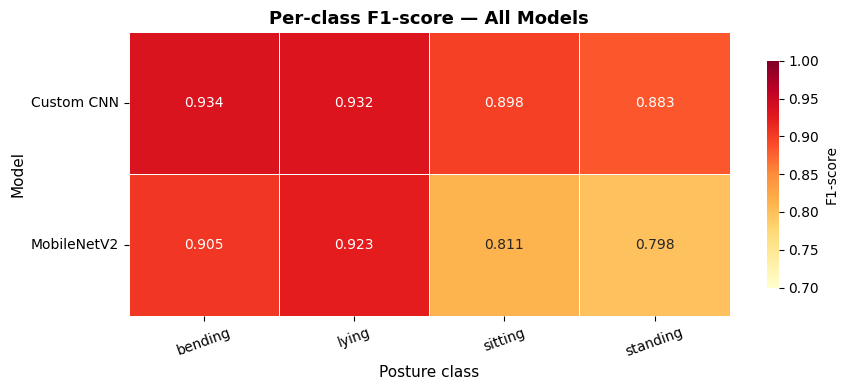


6.6  Best model selection
  🏆 Best model      : Custom CNN
     Test accuracy   : 91.11%
     Macro F1        : 0.9115
     Macro AUC       : 0.9870
     Inference time  : 3.17 ms/image

✅ Section 6 complete — full evaluation done.
   Figures saved     : fig9 – fig13
   Comparison table  : /kaggle/working/outputs/model_comparison_table.csv
   Best model        : Custom CNN


In [7]:
import time
 
# 6.0  SHARED EVALUATION UTILITIES
 
def get_predictions(model, dataset, use_efficientnet=False):
    """
    Run inference on a tf.data dataset.
    Returns:
        y_true  : true integer labels (numpy array)
        y_pred  : predicted integer labels (numpy array)
        y_proba : predicted probabilities for all classes (numpy array)
    """
    y_true_list, y_proba_list = [], []
 
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true_list.append(labels.numpy())
        y_proba_list.append(probs)
 
    y_true  = np.concatenate(y_true_list)
    y_proba = np.concatenate(y_proba_list)
    y_pred  = np.argmax(y_proba, axis=1)
    return y_true, y_pred, y_proba
 
 
def measure_inference_time(model, dataset, n_batches=10):
    """
    Measure average inference time per image (milliseconds).
    Runs n_batches warm-up batches first to avoid cold-start bias.
    """
    # Warm-up
    for images, _ in dataset.take(3):
        _ = model.predict(images, verbose=0)
 
    times = []
    batch_sizes = []
    for images, _ in dataset.take(n_batches):
        t0 = time.perf_counter()
        _  = model.predict(images, verbose=0)
        t1 = time.perf_counter()
        times.append(t1 - t0)
        batch_sizes.append(images.shape[0])
 
    total_images = sum(batch_sizes)
    total_time   = sum(times)
    ms_per_image = (total_time / total_images) * 1000
    return ms_per_image
 
 
def plot_confusion_matrix(y_true, y_pred, model_name, fig_filename):
    """Plot and save a styled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalised
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')
 
    for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ['Raw counts', 'Row-normalised (recall)'],
        ['d', '.2f']
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt,
            cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Predicted label', fontsize=11)
        ax.set_ylabel('True label', fontsize=11)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)
 
    plt.tight_layout()
    save_figure(fig, fig_filename)
    plt.show()
    return cm
 
 
def plot_roc_curves(y_true, y_proba, model_name, fig_filename):
    """
    Plot one-vs-rest ROC curves for every class + macro-average.
    Returns macro-average AUC.
    """
    # Binarise labels for one-vs-rest ROC
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
 
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
 
    auc_scores = {}
    for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores[cls_name] = roc_auc
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls_name}  (AUC = {roc_auc:.3f})')
 
    # Macro-average ROC
    all_fpr = np.unique(np.concatenate(
        [roc_curve(y_true_bin[:, i], y_proba[:, i])[0]
         for i in range(NUM_CLASSES)]
    ))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= NUM_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)
 
    ax.plot(all_fpr, mean_tpr, color='black', linewidth=2.5,
            linestyle='--', label=f'Macro-avg  (AUC = {macro_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1, alpha=0.5, label='Random')
 
    ax.set_title(f'ROC Curves (One-vs-Rest) — {model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
 
    plt.tight_layout()
    save_figure(fig, fig_filename)
    plt.show()
 
    return macro_auc, auc_scores
 
 
# 6.1  DEFINE ALL MODELS TO EVALUATE
print("=" * 55)
print("6.1  Models to evaluate on test set")
print("=" * 55)
print("  1. Custom CNN   (trained from scratch — Section 4)")
print("  2. MobileNetV2  (transfer learning — Section 5)")

models_to_evaluate = [
    {
        'name': 'Custom CNN',
        'model': custom_cnn,
        'test_ds': test_ds,
        'cm_fig': 'fig9_cm_custom_cnn.png',
        'roc_fig': 'fig10_roc_custom_cnn.png',
    },
    {
        'name': 'MobileNetV2',
        'model': model_mobilenet,
        'test_ds': test_ds,
        'cm_fig': 'fig11_cm_mobilenetv2.png',
        'roc_fig': 'fig12_roc_mobilenetv2.png',
    },
]
 
# 6.2  EVALUATE EACH MODEL
print("\n" + "=" * 55)
print("6.2  Running test-set evaluation")
print("=" * 55)
 
eval_results = []   # list of result dicts, one per model
 
for entry in models_to_evaluate:
    name  = entry['name']
    model = entry['model']
    ds    = entry['test_ds']
 
    print(f"\n  ── {name} ──")
 
    # Predictions
    y_true, y_pred, y_proba = get_predictions(model, ds)
 
    # Inference time
    ms_per_img = measure_inference_time(model, ds)
 
    # Confusion matrix
    cm = plot_confusion_matrix(y_true, y_pred, name, entry['cm_fig'])
 
    # Classification report
    report_str = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
    print(f"\n  Classification Report — {name}")
    print(report_str)
 
    # Per-class metrics dict
    report_dict = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
 
    # ROC-AUC
    macro_auc, class_aucs = plot_roc_curves(y_true, y_proba, name, entry['roc_fig'])
 
    # Overall accuracy
    test_accuracy = np.mean(y_true == y_pred)
 
    print(f"  Test accuracy  : {test_accuracy*100:.2f}%")
    print(f"  Macro AUC      : {macro_auc:.4f}")
    print(f"  Inference time : {ms_per_img:.2f} ms/image")
 
    eval_results.append({
        'Model':          name,
        'Test Accuracy':  test_accuracy,
        'Macro F1':       report_dict['macro avg']['f1-score'],
        'Macro Precision':report_dict['macro avg']['precision'],
        'Macro Recall':   report_dict['macro avg']['recall'],
        'Macro AUC':      macro_auc,
        'Inference (ms)': ms_per_img,
        'y_true':         y_true,
        'y_pred':         y_pred,
        'y_proba':        y_proba,
        'report_dict':    report_dict,
        'cm':             cm,
    })
 
# 6.3  MODEL COMPARISON TABLE
print("\n" + "=" * 55)
print("6.3  Model Comparison Table")
print("=" * 55)
 
comparison_df = pd.DataFrame([{
    'Model':           r['Model'],
    'Test Acc (%)':    round(r['Test Accuracy'] * 100, 2),
    'Macro F1':        round(r['Macro F1'], 4),
    'Macro Precision': round(r['Macro Precision'], 4),
    'Macro Recall':    round(r['Macro Recall'], 4),
    'Macro AUC':       round(r['Macro AUC'], 4),
    'Infer. (ms/img)': round(r['Inference (ms)'], 2),
} for r in eval_results])
 
comparison_df = comparison_df.sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)
comparison_df.index += 1   # rank starts at 1
 
print(comparison_df.to_string())
 
# Save comparison table as CSV
table_path = OUTPUT_DIR / 'model_comparison_table.csv'
comparison_df.to_csv(table_path)
print(f"\n  Table saved → {table_path}")

# 6.4  COMPARISON BAR CHART
print("\n" + "=" * 55)
print("6.4  Comparison bar chart")
print("=" * 55)
 
metrics   = ['Test Acc (%)', 'Macro F1', 'Macro Precision', 'Macro Recall', 'Macro AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
fig.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
 
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
model_names = comparison_df['Model'].tolist()
 
for ax, metric in zip(axes, metrics):
    values = comparison_df[metric].tolist()
    # Normalise for display if metric is percentage
    display_vals = [v / 100 if metric == 'Test Acc (%)' else v for v in values]
 
    bars = ax.bar(model_names, display_vals, color=colors[:len(model_names)],
                  edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)
 
    for bar, val in zip(bars, display_vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
save_figure(fig, 'fig17_model_comparison_bar.png')
plt.show()
 
# 6.5  PER-CLASS F1 HEATMAP
print("\n" + "=" * 55)
print("6.5  Per-class F1 heatmap")
print("=" * 55)
 
# Build a heatmap: rows = models, columns = classes
f1_matrix = []
for r in eval_results:
    row = [r['report_dict'][cls]['f1-score'] for cls in CLASS_NAMES]
    f1_matrix.append(row)
 
f1_df = pd.DataFrame(
    f1_matrix,
    index=[r['Model'] for r in eval_results],
    columns=CLASS_NAMES
)
 
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    f1_df, annot=True, fmt='.3f',
    cmap='YlOrRd', ax=ax,
    vmin=0.7, vmax=1.0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'F1-score', 'shrink': 0.8}
)
ax.set_title('Per-class F1-score — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Posture class', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
 
plt.tight_layout()
save_figure(fig, 'fig18_perclass_f1_heatmap.png')
plt.show()
 
# 6.6  IDENTIFY BEST MODEL
print("\n" + "=" * 55)
print("6.6  Best model selection")
print("=" * 55)
 
best_row       = comparison_df.iloc[0]
best_model_name = best_row['Model']
 
print(f"  🏆 Best model      : {best_model_name}")
print(f"     Test accuracy   : {best_row['Test Acc (%)']:.2f}%")
print(f"     Macro F1        : {best_row['Macro F1']:.4f}")
print(f"     Macro AUC       : {best_row['Macro AUC']:.4f}")
print(f"     Inference time  : {best_row['Infer. (ms/img)']:.2f} ms/image")
 
# Retrieve the best model object for use in Section 7 (Grad-CAM)
best_model_entry = next(e for e in models_to_evaluate
                        if e['name'] == best_model_name)
best_model       = best_model_entry['model']
best_test_ds     = best_model_entry['test_ds']
 
# Also store the best model's predictions for Grad-CAM
best_result = next(r for r in eval_results if r['Model'] == best_model_name)
best_y_true = best_result['y_true']
best_y_pred = best_result['y_pred']
 
print("\n✅ Section 6 complete — full evaluation done.")
print(f"   Figures saved     : fig9 – fig13")
print(f"   Comparison table  : {table_path}")
print(f"   Best model        : {best_model_name}")
 

7.0  Grad-CAM Implementation

  Grad-CAM (Gradient-weighted Class Activation Mapping):
    1. Pick the last convolutional layer in the model
    2. Run a forward pass and record:
         - the feature maps output by that layer
         - the gradients of the predicted class score
           with respect to those feature maps
    3. Global-average-pool the gradients → per-channel weights
    4. Weighted sum of feature maps → raw heatmap
    5. ReLU → keep only positive activations
    6. Resize heatmap to input image size
    7. Overlay on original image with a colour map

  ✅ Grad-CAM functions defined.

7.1  Building Grad-CAM model
  Applying Grad-CAM to: Custom CNN
  Grad-CAM target layer: conv4_2

7.3  Grad-CAM — Correct predictions (one per class)
   Figure saved → /kaggle/working/outputs/figures/fig19_gradcam_correct.png


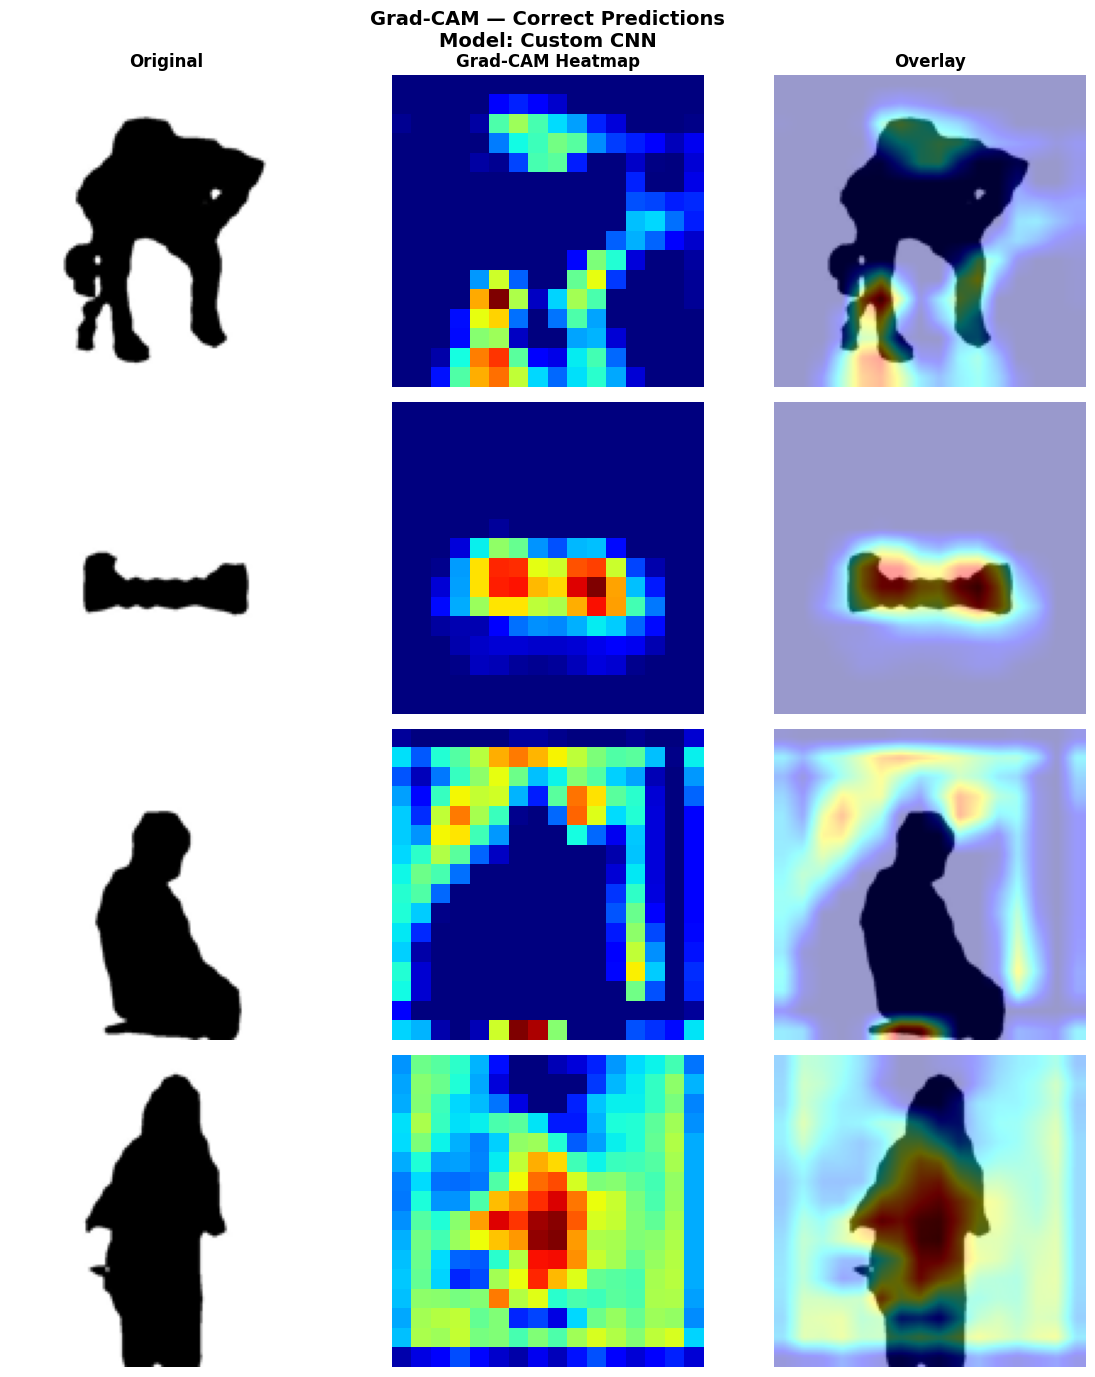

  Saved: fig19_gradcam_correct.png

7.4  Grad-CAM — Misclassifications (false positives/negatives)
  Found 6 misclassified samples to visualise.
   Figure saved → /kaggle/working/outputs/figures/fig20_gradcam_errors.png


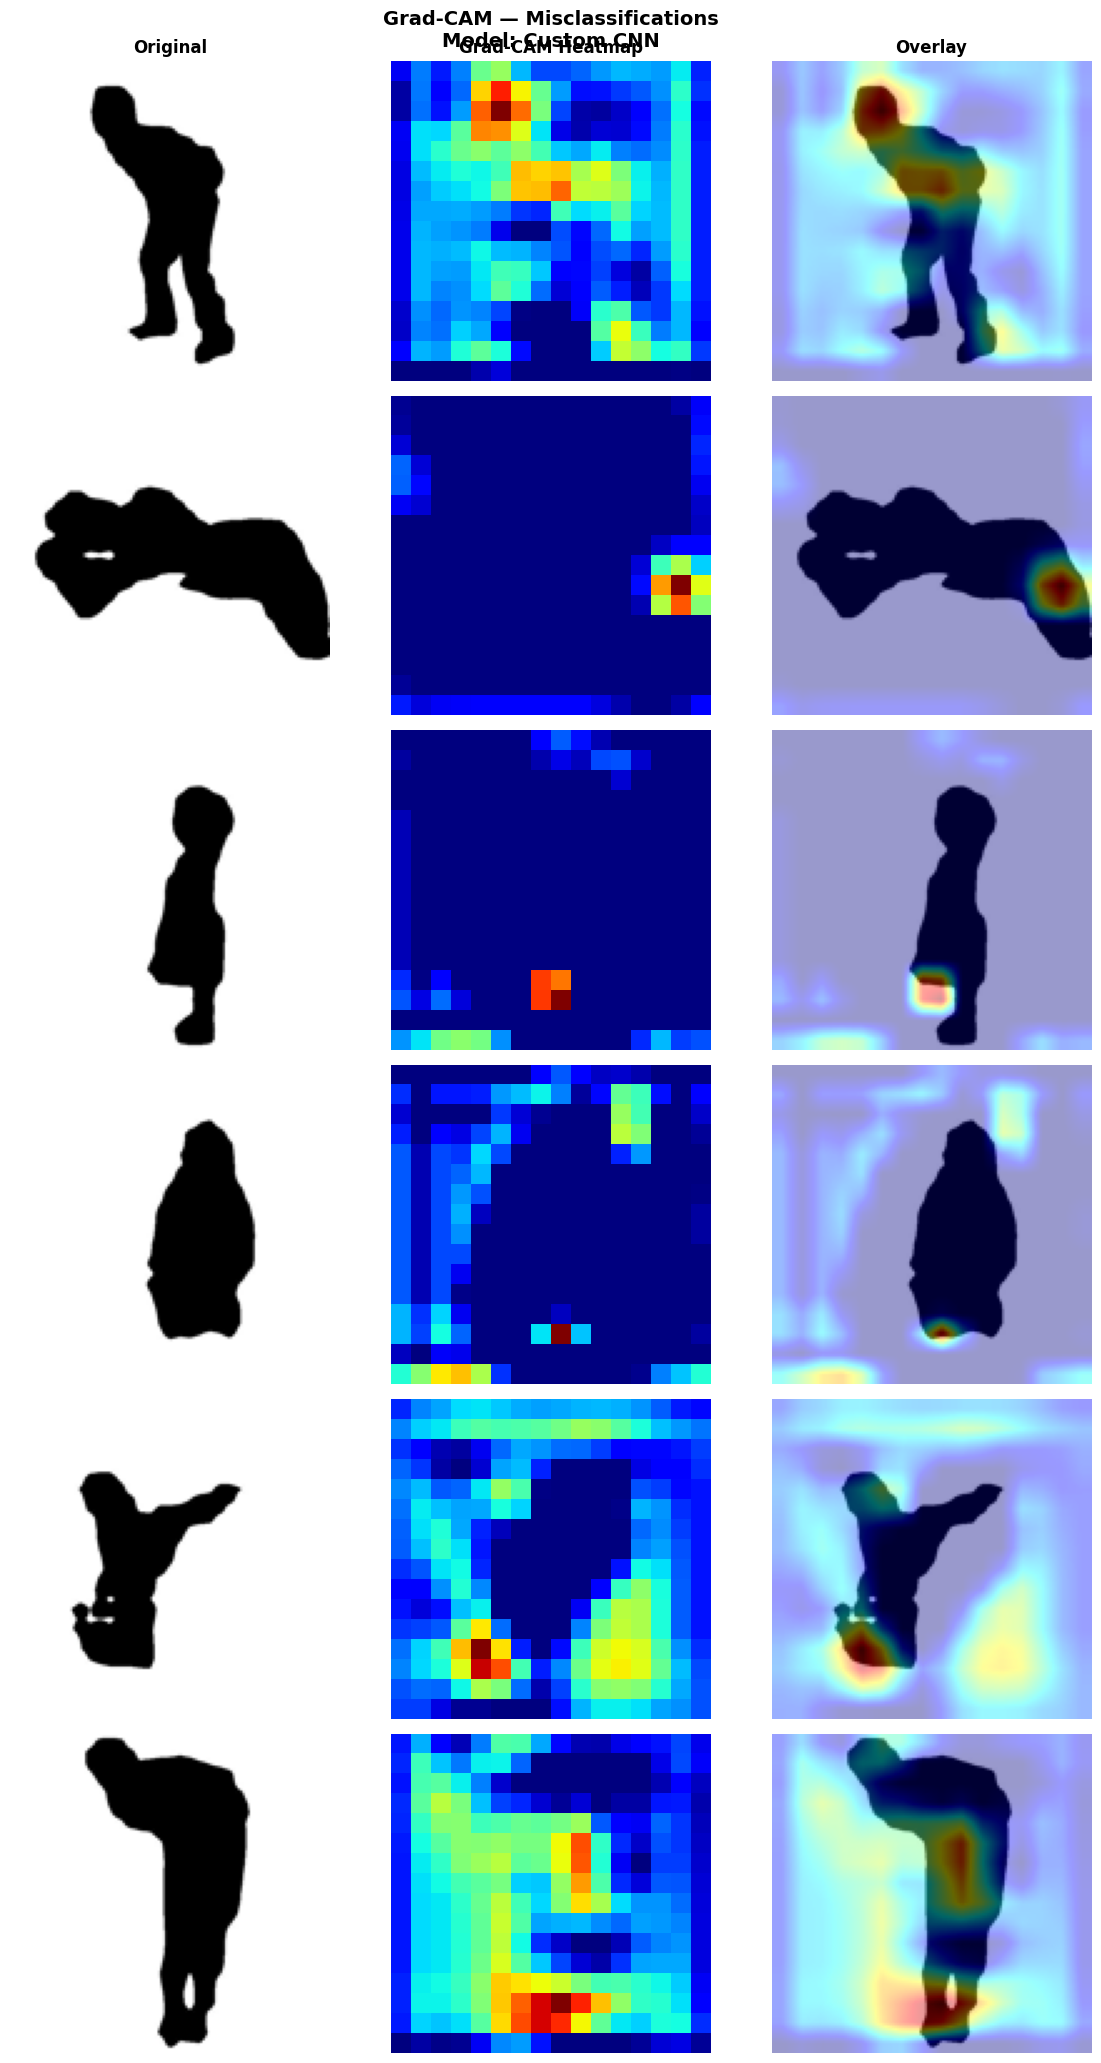

  Saved: fig20_gradcam_errors.png

7.5  Grad-CAM — Both models on the same image
  Shows how Custom CNN and MobileNetV2 attend to different regions.
  Grad-CAM target layer: conv4_2
  Grad-CAM target layer: Conv_1
   Figure saved → /kaggle/working/outputs/figures/fig21_gradcam_allmodels_bending.png


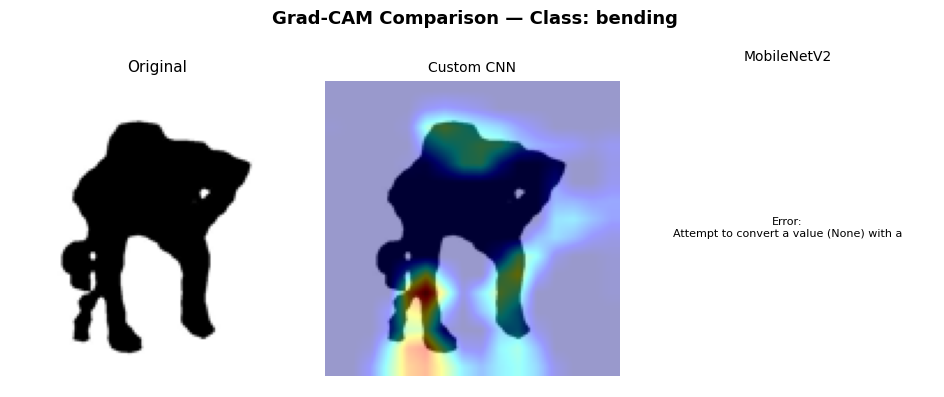

  Saved: fig21_gradcam_allmodels_bending.png
  Grad-CAM target layer: conv4_2
  Grad-CAM target layer: Conv_1
   Figure saved → /kaggle/working/outputs/figures/fig21_gradcam_allmodels_lying.png


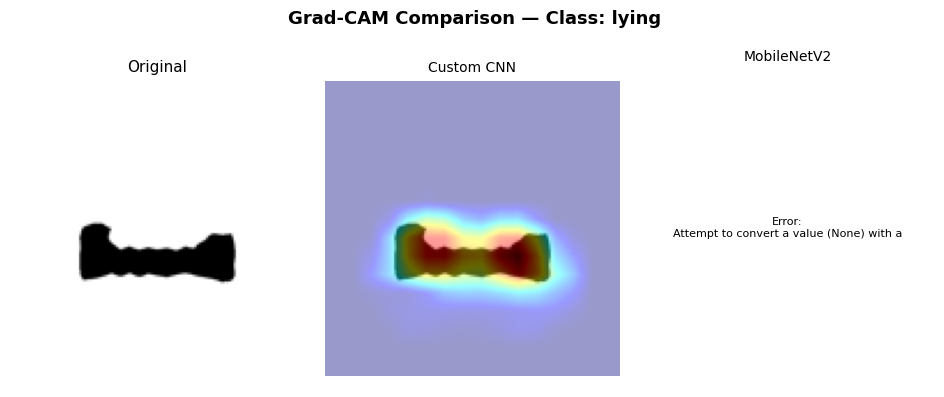

  Saved: fig21_gradcam_allmodels_lying.png
  Grad-CAM target layer: conv4_2
  Grad-CAM target layer: Conv_1
   Figure saved → /kaggle/working/outputs/figures/fig21_gradcam_allmodels_sitting.png


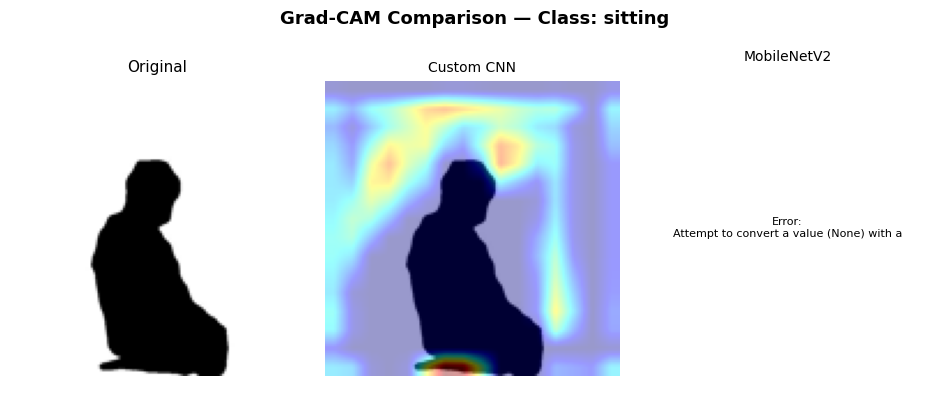

  Saved: fig21_gradcam_allmodels_sitting.png
  Grad-CAM target layer: conv4_2
  Grad-CAM target layer: Conv_1
   Figure saved → /kaggle/working/outputs/figures/fig21_gradcam_allmodels_standing.png


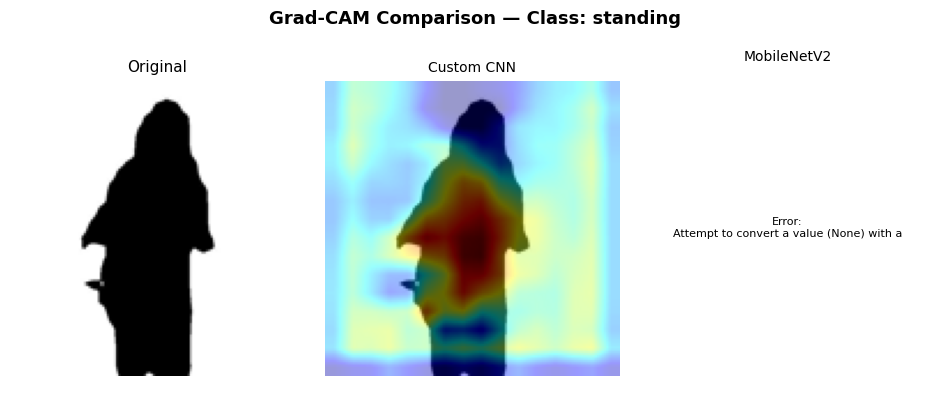

  Saved: fig21_gradcam_allmodels_standing.png

7.6  Grad-CAM interpretation guide
✅ Section 7 complete — Grad-CAM visualisations done.
   Figures saved: fig19 – fig21


In [8]:
# 7.0  GRAD-CAM IMPLEMENTATION
print("=" * 55)
print("7.0  Grad-CAM Implementation")
print("=" * 55)
print("""
  Grad-CAM (Gradient-weighted Class Activation Mapping):
    1. Pick the last convolutional layer in the model
    2. Run a forward pass and record:
         - the feature maps output by that layer
         - the gradients of the predicted class score
           with respect to those feature maps
    3. Global-average-pool the gradients → per-channel weights
    4. Weighted sum of feature maps → raw heatmap
    5. ReLU → keep only positive activations
    6. Resize heatmap to input image size
    7. Overlay on original image with a colour map
""")
 
 
def find_last_conv_layer(model):
    """
    Find the name of the last Conv2D layer in the model.
    For transfer learning models, searches inside the base model.
    """
    last_conv = None
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            last_conv = layer.name
        # If this layer is itself a model (e.g. the base network), recurse
        elif hasattr(layer, 'layers'):
            for sub_layer in layer.layers:
                if isinstance(sub_layer, layers.Conv2D):
                    last_conv = sub_layer.name
    return last_conv
 
 
def get_gradcam_model(model):
    """
    Build a Grad-CAM sub-model that outputs:
        (last_conv_feature_maps, final_predictions)
    Works for both custom CNN and transfer learning models.
    """
    # For transfer learning models, the base is a sub-model.
    # We need to find the last conv layer across the full graph.
    last_conv_name = None
 
    for layer in reversed(model.layers):
        # Direct Conv2D layer in the top-level model
        if isinstance(layer, layers.Conv2D):
            last_conv_name = layer.name
            break
        # Sub-model (e.g. MobileNetV2 base) — search inside
        if hasattr(layer, 'layers'):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, layers.Conv2D):
                    last_conv_name = sub_layer.name
                    break
            if last_conv_name:
                break
 
    if last_conv_name is None:
        raise ValueError("No Conv2D layer found in model.")
 
    print(f"  Grad-CAM target layer: {last_conv_name}")
 
    # Build a model that outputs both the conv feature maps and predictions
    # We need to handle nested models (transfer learning) differently
    try:
        # Try direct access first (custom CNN)
        conv_layer   = model.get_layer(last_conv_name)
        gradcam_model = keras.Model(
            inputs=model.inputs,
            outputs=[conv_layer.output, model.output]
        )
    except ValueError:
        # For nested models, walk through layers to find the output
        # Build by tracing the computation graph
        for layer in model.layers:
            if hasattr(layer, 'layers'):
                try:
                    sub_conv   = layer.get_layer(last_conv_name)
                    # Create intermediate model up to last conv in base
                    base_conv_model = keras.Model(
                        inputs=layer.input,
                        outputs=sub_conv.output
                    )
                    # Chain: full model input → base conv output + full output
                    inp      = model.inputs[0]
                    conv_out = base_conv_model(inp)
                    gradcam_model = keras.Model(
                        inputs=inp,
                        outputs=[conv_out, model.output]
                    )
                    break
                except Exception:
                    continue
 
    return gradcam_model
 
 
def compute_gradcam(gradcam_model, img_tensor, class_idx):
    """
    Compute the Grad-CAM heatmap for a single image and target class.

    Args:
        gradcam_model : model with two outputs (conv_maps, predictions)
        img_tensor    : (1, H, W, C) float32 tensor
        class_idx     : integer index of the target class

    Returns:
        heatmap : (H, W) numpy array with values in [0, 1]
    """

    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(
            img_tensor,
            training=False
        )

        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    heatmap_max = tf.reduce_max(heatmap)

    if heatmap_max > 0:
        heatmap = heatmap / heatmap_max

    return heatmap.numpy()

def compute_gradcam(gradcam_model, img_tensor, class_idx):
    """
    Compute the Grad-CAM heatmap for a single image and target class.

    Args:
        gradcam_model : model with two outputs (conv_maps, predictions)
        img_tensor    : (1, H, W, C) float32 tensor
        class_idx     : integer index of the target class

    Returns:
        heatmap : (H, W) numpy array with values in [0, 1]
    """

    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(
            img_tensor,
            training=False
        )

        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    heatmap_max = tf.reduce_max(heatmap)

    if heatmap_max > 0:
        heatmap = heatmap / heatmap_max

    return heatmap.numpy()
 
 
def overlay_gradcam(original_img, heatmap, alpha=0.4):
    """
    Overlay a Grad-CAM heatmap on the original image.
 
    Args:
        original_img : (H, W, 3) float32 array in [0, 1]
        heatmap      : (h, w) float32 array in [0, 1]
        alpha        : heatmap opacity (0 = invisible, 1 = opaque)
 
    Returns:
        overlay : (H, W, 3) uint8 array
    """
    H, W = original_img.shape[:2]
 
    # Resize heatmap to match input image
    heatmap_resized = cv2.resize(heatmap, (W, H))
 
    # Apply colour map (JET: blue=low, red=high activation)
    heatmap_color = cv2.applyColorMap(
        (heatmap_resized * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
 
    # Original image to uint8
    original_uint8 = (original_img * 255).astype(np.uint8)
 
    # Blend: overlay = alpha * heatmap + (1 - alpha) * original
    overlay = (alpha * heatmap_color + (1 - alpha) * original_uint8).astype(np.uint8)
    return overlay
 
 
print("  ✅ Grad-CAM functions defined.")
 
# 7.1  BUILD GRAD-CAM MODEL
print("\n" + "=" * 55)
print("7.1  Building Grad-CAM model")
print("=" * 55)
print(f"  Applying Grad-CAM to: {best_model_name}")
 
gradcam_model = get_gradcam_model(best_model)
 
# 7.2  HELPER: LOAD RAW TEST IMAGES
 
def load_raw_image(path):
    """Load a single image as a normalised (H, W, 3) float32 array."""
    img = Image.open(path).convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    return np.array(img, dtype=np.float32) / 255.0
 
 
def predict_single(model, img_array):
    """Predict class probabilities for a single (H, W, C) image array."""
    tensor = tf.expand_dims(tf.cast(img_array, tf.float32), 0)
    probs  = model.predict(tensor, verbose=0)[0]
    return probs
 
# 7.3  GRAD-CAM ON CORRECT PREDICTIONS (one per class)
print("\n" + "=" * 55)
print("7.3  Grad-CAM — Correct predictions (one per class)")
print("=" * 55)
 
# Find one correctly predicted test image for each class
correct_samples = {cls: None for cls in CLASS_NAMES}
 
for path, true_lbl, pred_lbl in zip(X_test, best_y_true, best_y_pred):
    cls_name = IDX_TO_CLASS[true_lbl]
    if true_lbl == pred_lbl and correct_samples[cls_name] is None:
        correct_samples[cls_name] = (path, true_lbl)
    if all(v is not None for v in correct_samples.values()):
        break
 
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, NUM_CLASSES * 3.5))
fig.suptitle(f'Grad-CAM — Correct Predictions\nModel: {best_model_name}',
             fontsize=14, fontweight='bold')
 
col_titles = ['Original', 'Grad-CAM Heatmap', 'Overlay']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')
 
for row_idx, cls_name in enumerate(CLASS_NAMES):
    path, true_idx = correct_samples[cls_name]
    img_array = load_raw_image(path)
    probs     = predict_single(best_model, img_array)
    pred_idx  = np.argmax(probs)
    confidence = probs[pred_idx] * 100
 
    img_tensor = tf.expand_dims(tf.cast(img_array, tf.float32), 0)
    heatmap    = compute_gradcam(gradcam_model, img_tensor, pred_idx)
    overlay    = overlay_gradcam(img_array, heatmap)
 
    # Original
    axes[row_idx][0].imshow(img_array)
    axes[row_idx][0].set_ylabel(f'{cls_name}\n(True)', fontsize=11, fontweight='bold')
    axes[row_idx][0].axis('off')
 
    # Heatmap only
    axes[row_idx][1].imshow(heatmap, cmap='jet')
    axes[row_idx][1].axis('off')
 
    # Overlay
    axes[row_idx][2].imshow(overlay)
    axes[row_idx][2].set_xlabel(f'Pred: {cls_name}  ({confidence:.1f}%)',
                                fontsize=10)
    axes[row_idx][2].axis('off')
 
plt.tight_layout()
save_figure(fig, 'fig19_gradcam_correct.png')
plt.show()
print("  Saved: fig19_gradcam_correct.png")
 
# 7.4  GRAD-CAM ON MISCLASSIFICATIONS
print("\n" + "=" * 55)
print("7.4  Grad-CAM — Misclassifications (false positives/negatives)")
print("=" * 55)
 
# Collect up to 6 misclassified test images
misclassified = []
for path, true_lbl, pred_lbl in zip(X_test, best_y_true, best_y_pred):
    if true_lbl != pred_lbl:
        misclassified.append((path, true_lbl, pred_lbl))
    if len(misclassified) >= 6:
        break
 
n_mis = len(misclassified)
print(f"  Found {n_mis} misclassified samples to visualise.")
 
if n_mis > 0:
    fig, axes = plt.subplots(n_mis, 3, figsize=(12, n_mis * 3.5))
    if n_mis == 1:
        axes = np.expand_dims(axes, 0)   # handle single-row case
    fig.suptitle(f'Grad-CAM — Misclassifications\nModel: {best_model_name}',
                 fontsize=14, fontweight='bold')
 
    for ax, title in zip(axes[0], ['Original', 'Grad-CAM Heatmap', 'Overlay']):
        ax.set_title(title, fontsize=12, fontweight='bold')
 
    for row_idx, (path, true_lbl, pred_lbl) in enumerate(misclassified):
        img_array  = load_raw_image(path)
        probs      = predict_single(best_model, img_array)
        confidence = probs[pred_lbl] * 100
 
        img_tensor = tf.expand_dims(tf.cast(img_array, tf.float32), 0)
 
        # Heatmap for the PREDICTED class (what the model was attending to)
        heatmap_pred = compute_gradcam(gradcam_model, img_tensor, pred_lbl)
        overlay_pred = overlay_gradcam(img_array, heatmap_pred)
 
        true_name = IDX_TO_CLASS[true_lbl]
        pred_name = IDX_TO_CLASS[pred_lbl]
 
        axes[row_idx][0].imshow(img_array)
        axes[row_idx][0].set_ylabel(f'True: {true_name}', fontsize=10, color='green')
        axes[row_idx][0].axis('off')
 
        axes[row_idx][1].imshow(heatmap_pred, cmap='jet')
        axes[row_idx][1].axis('off')
 
        axes[row_idx][2].imshow(overlay_pred)
        axes[row_idx][2].set_xlabel(
            f'Pred: {pred_name}  ({confidence:.1f}%)  ✗',
            fontsize=10, color='red'
        )
        axes[row_idx][2].axis('off')
 
    plt.tight_layout()
    save_figure(fig, 'fig20_gradcam_errors.png')
    plt.show()
    print("  Saved: fig20_gradcam_errors.png")
else:
    print("  ⚠️  No misclassifications found — model classified all test images correctly!")
 
# 7.5  GRAD-CAM SIDE-BY-SIDE: ALL MODELS ON THE SAME IMAGE
print("\n" + "=" * 55)
print("7.5  Grad-CAM — Both models on the same image")
print("=" * 55)
print("  Shows how Custom CNN and MobileNetV2 attend to different regions.")
 
# Pick one image per class (use the correct samples from 7.3)
all_model_entries = [
    ('Custom CNN',   custom_cnn,      False),
    ('MobileNetV2',  model_mobilenet, False),
]
 
for cls_name in CLASS_NAMES:
    path, true_idx = correct_samples[cls_name]
    img_array = load_raw_image(path)
 
    n_models = len(all_model_entries)
    fig, axes = plt.subplots(1, n_models + 1, figsize=((n_models + 1) * 3.2, 4))
    fig.suptitle(f'Grad-CAM Comparison — Class: {cls_name}',
                 fontsize=13, fontweight='bold')
 
    # Original
    axes[0].imshow(img_array)
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')
 
    for ax, (m_name, m_obj, _) in zip(axes[1:], all_model_entries):
        try:
            gcam_model = get_gradcam_model(m_obj)
            tensor     = tf.expand_dims(tf.cast(img_array, tf.float32), 0)
            heatmap    = compute_gradcam(gcam_model, tensor, true_idx)
            overlay    = overlay_gradcam(img_array, heatmap)
            ax.imshow(overlay)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error:\n{str(e)[:40]}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_title(m_name, fontsize=10)
        ax.axis('off')
 
    plt.tight_layout()
    fname = f'fig21_gradcam_allmodels_{cls_name.lower()}.png'
    save_figure(fig, fname)
    plt.show()
    print(f"  Saved: {fname}")
 
# 7.6  GRAD-CAM INTERPRETATION SUMMARY
print("\n" + "=" * 55)
print("7.6  Grad-CAM interpretation guide")
print("=" * 55)
 
print("✅ Section 7 complete — Grad-CAM visualisations done.")
print("   Figures saved: fig19 – fig21")


#Grad-CAM visualization for MobileNetV2 could not be generated for one sample due to layer compatibility issues.
 

In [9]:
!zip -r project_outputs.zip /kaggle/working/outputs

  adding: kaggle/working/outputs/ (stored 0%)
  adding: kaggle/working/outputs/model_comparison_table.csv (deflated 24%)
  adding: kaggle/working/outputs/figures/ (stored 0%)
  adding: kaggle/working/outputs/figures/fig3_pixel_distribution.png (deflated 15%)
  adding: kaggle/working/outputs/figures/fig21_gradcam_allmodels_standing.png (deflated 11%)
  adding: kaggle/working/outputs/figures/fig1_class_distribution.png (deflated 12%)
  adding: kaggle/working/outputs/figures/fig12_roc_mobilenetv2.png (deflated 11%)
  adding: kaggle/working/outputs/figures/fig19_gradcam_correct.png (deflated 14%)
  adding: kaggle/working/outputs/figures/fig20_gradcam_errors.png (deflated 15%)
  adding: kaggle/working/outputs/figures/fig17_model_comparison_bar.png (deflated 25%)
  adding: kaggle/working/outputs/figures/fig2_sample_images.png (deflated 10%)
  adding: kaggle/working/outputs/figures/fig9_cm_custom_cnn.png (deflated 13%)
  adding: kaggle/working/outputs/figures/fig6_mobilenetv2_curves.png (defl

In [10]:
import os
print(os.listdir('/kaggle/working'))

['outputs', '.virtual_documents', 'project_outputs.zip']


In [11]:
import shutil

shutil.copy(
    "/kaggle/working/.virtual_documents/__notebook_source__.ipynb",
    "/kaggle/working/Human_Posture_Classification.ipynb"
)

print("Notebook copied!")

Notebook copied!
